In [1]:
all_position = []
all_width = []

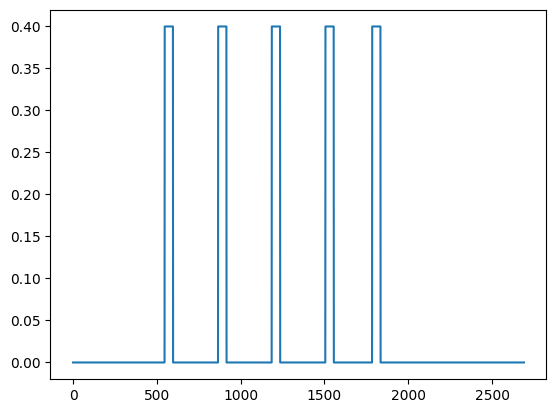

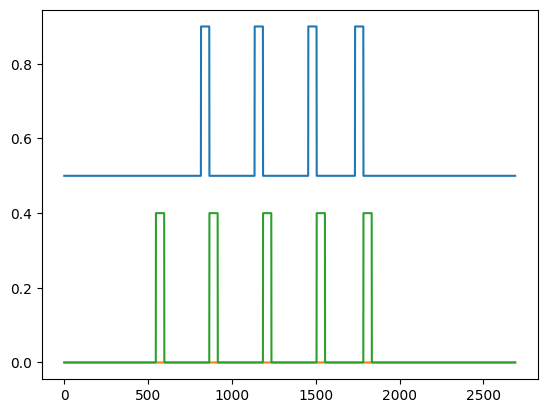

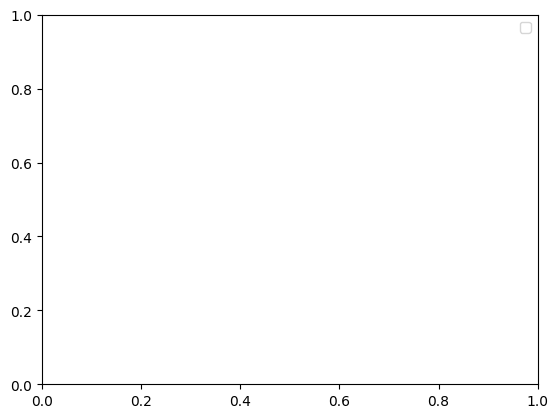

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    #period = 0.5+.15*2*(np.random.uniform()-.5);
    period = np.random.uniform()
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    
    a = np.where(fin != 0)
    
    a = np.array_split(a[0],5)
    
    
    #concatenate with time delay
    idx = a[4][0]
    
    #early
    fin = np.concatenate((fin[:idx-40], fin[idx:],np.zeros((40,1))), axis=0)

    
    
    #late
    #fin = np.concatenate((fin[:idx], np.zeros((40, 1)), fin[idx:-40]), axis=0)
    #fin = fin[:-20]
    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    
    
    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.019 seconds late
The width of the predicted pulse at half-max is 155.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.005 seconds early
The width of the predicted pulse at half-max is 112.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.041 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.008 seconds early
The width of the predicted pulse at half-max is 150.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.009000000000000001 seconds late
The width of the predicted pulse at half-max is 147.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.025 seconds late
The width of the predicted pulse at half-max is 

C:\Users\Manav\AppData\Local\Temp\ipykernel_8840\3981172340.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,4))


....
Testing: 10 trials
..........
The predicted pulse peak is 0.049 seconds late
The width of the predicted pulse at half-max is 112.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.035 seconds late
The width of the predicted pulse at half-max is 305.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.006 seconds late
The width of the predicted pulse at half-max is 292.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.035 seconds late
The width of the predicted pulse at half-max is 110.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.049 seconds late
The width of the predicted pulse at half-max is 190.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.041 seconds late
The width of the predicted pulse at half-max is 177.5% the size of input
Initi

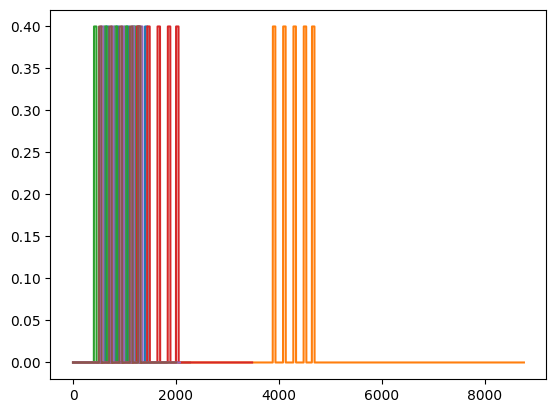

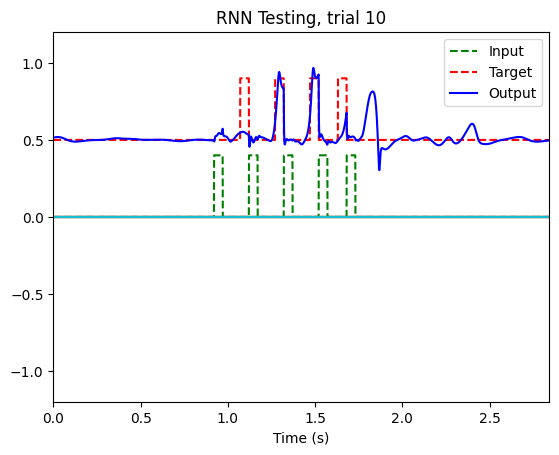

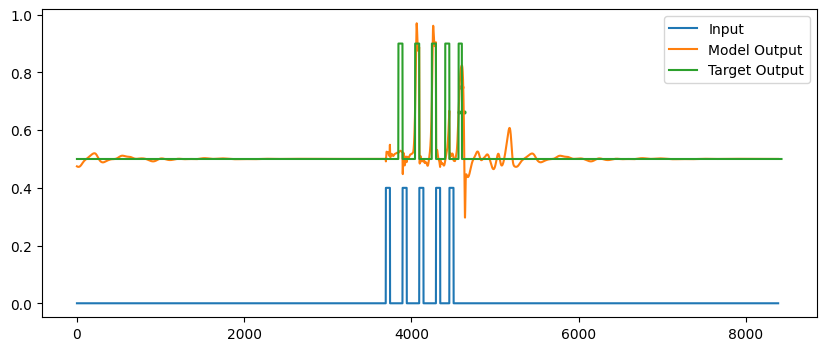

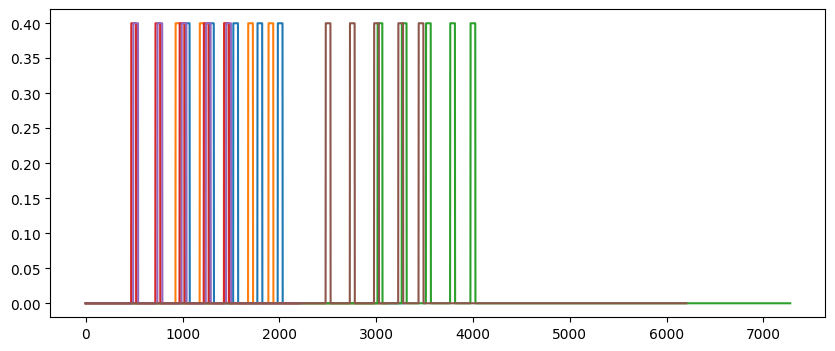

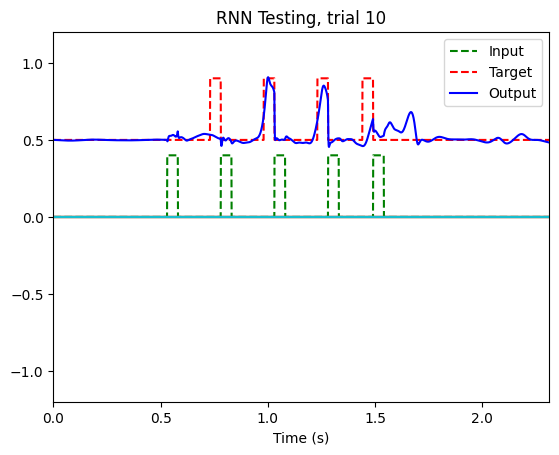

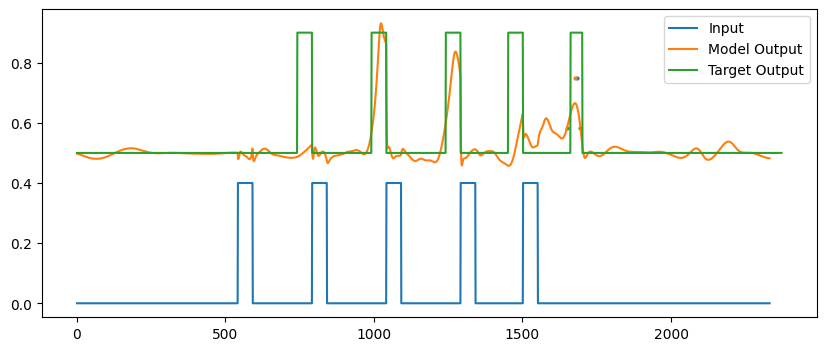

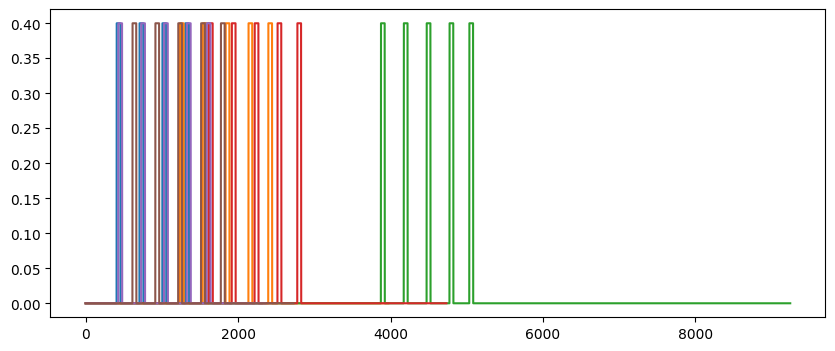

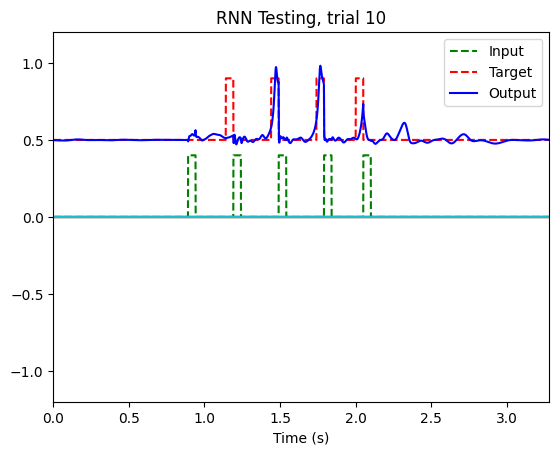

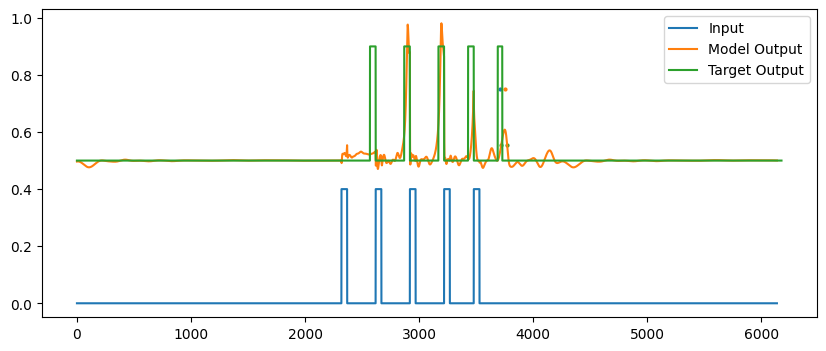

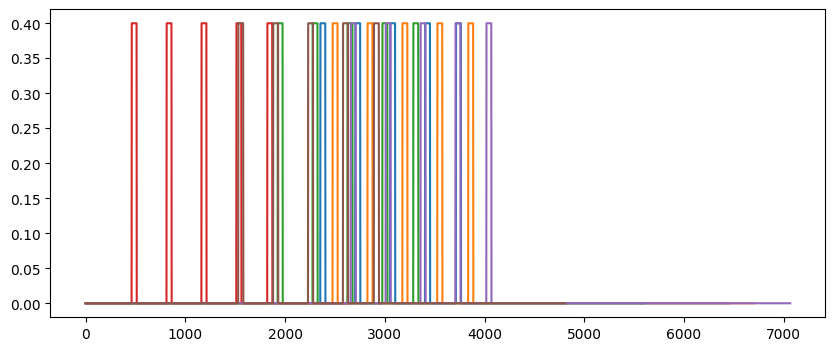

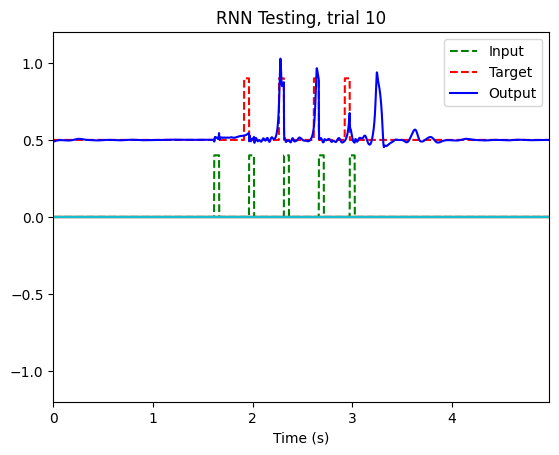

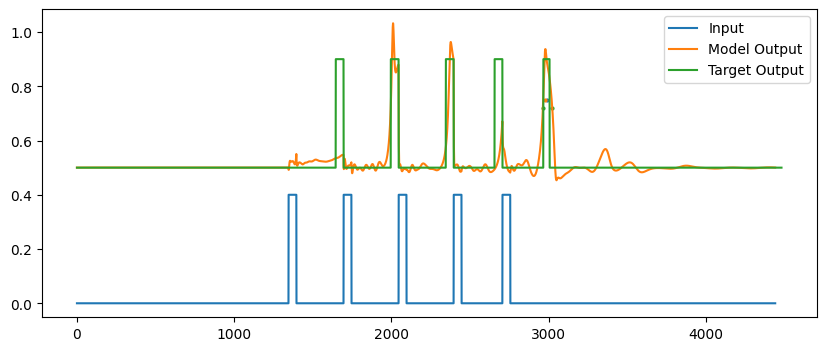

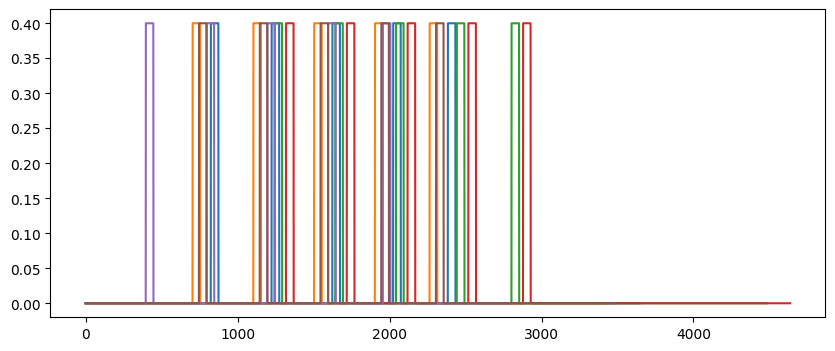

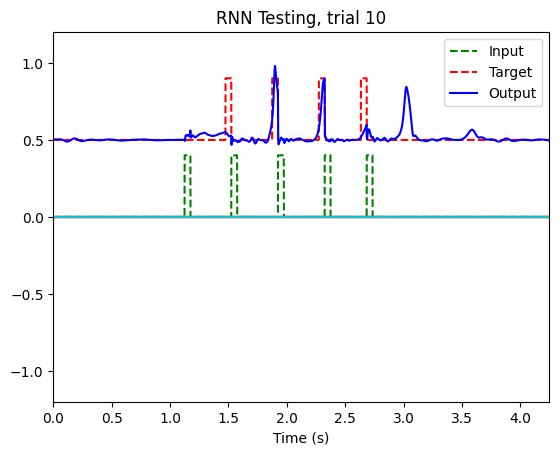

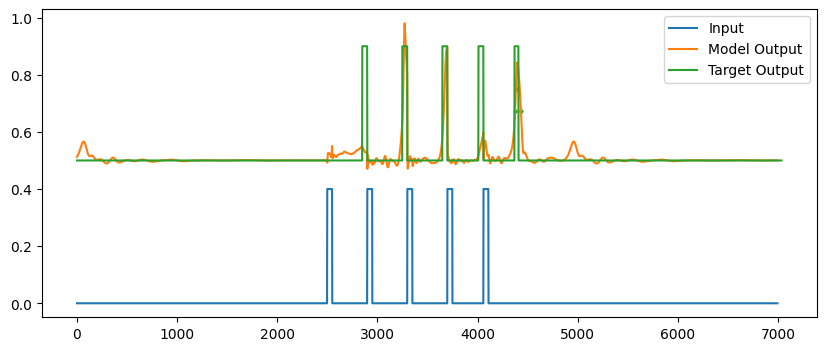

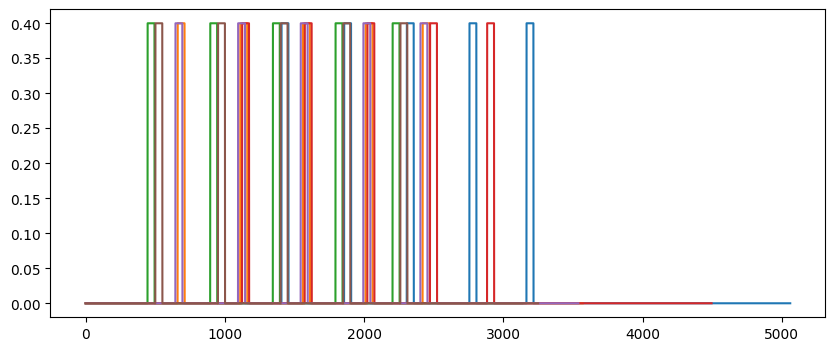

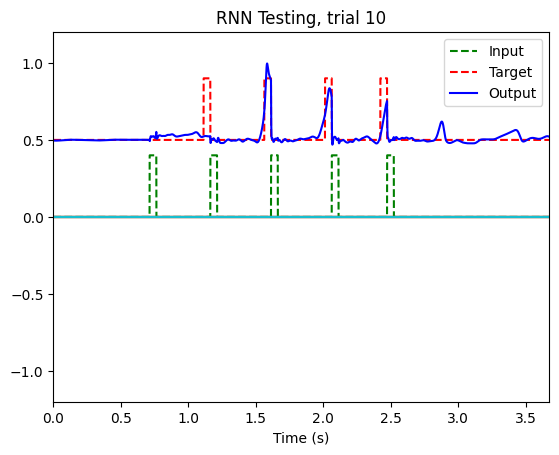

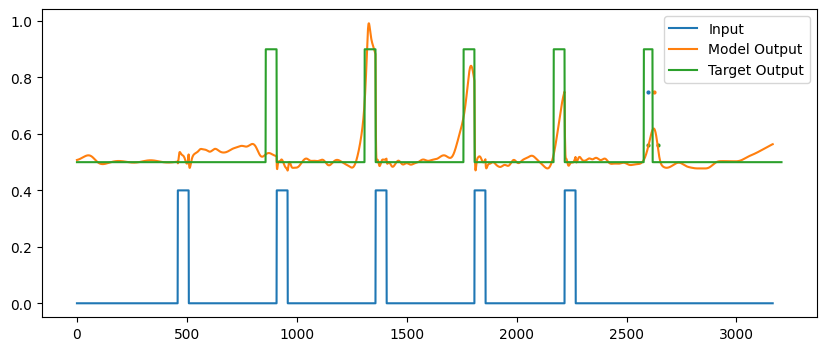

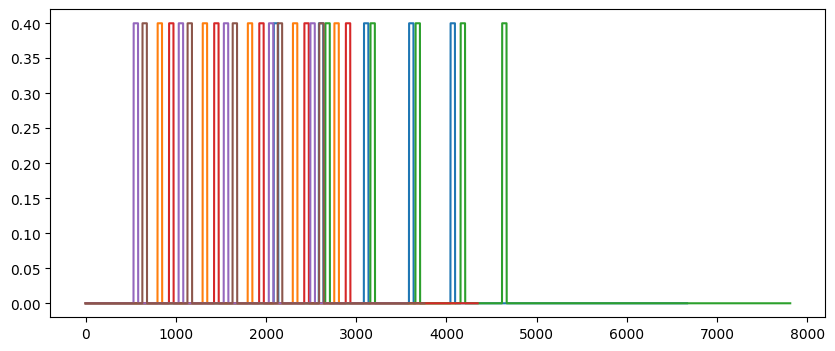

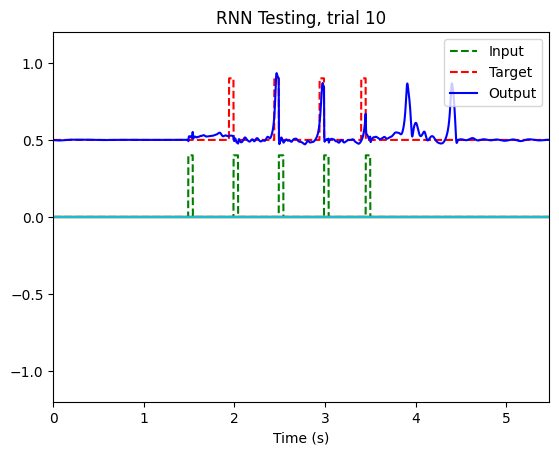

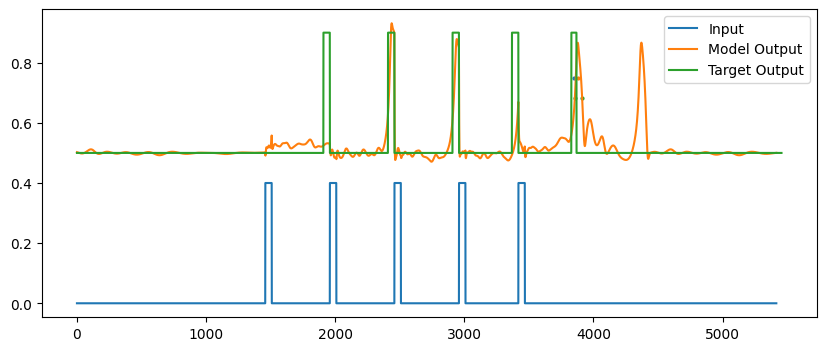

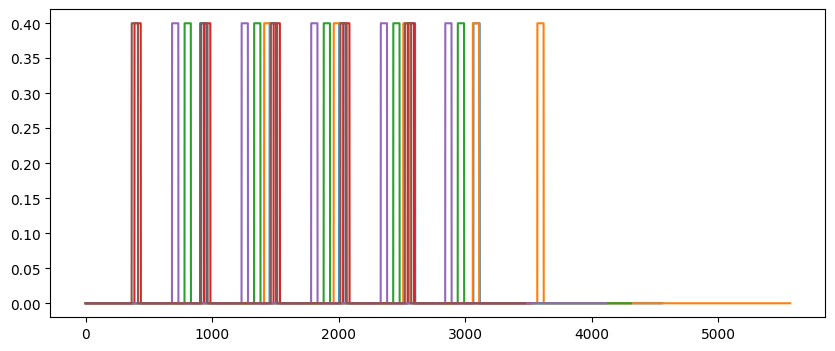

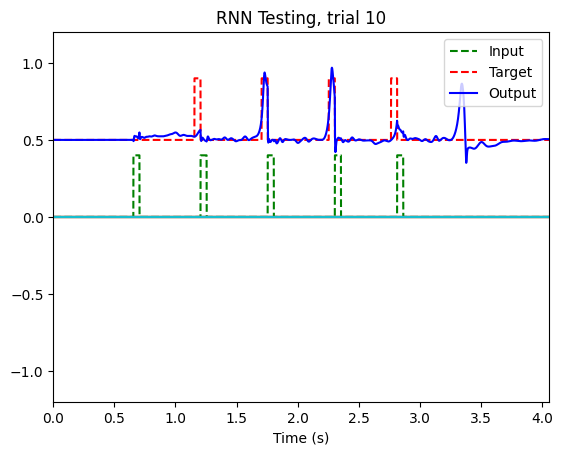

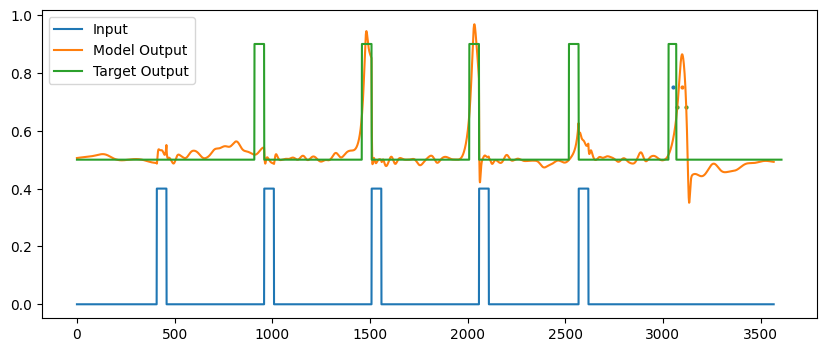

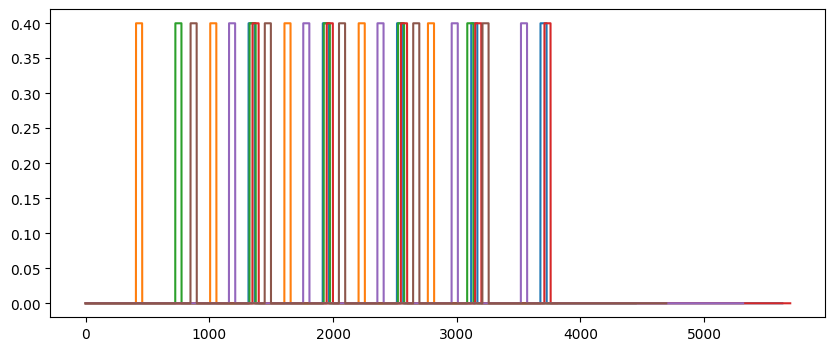

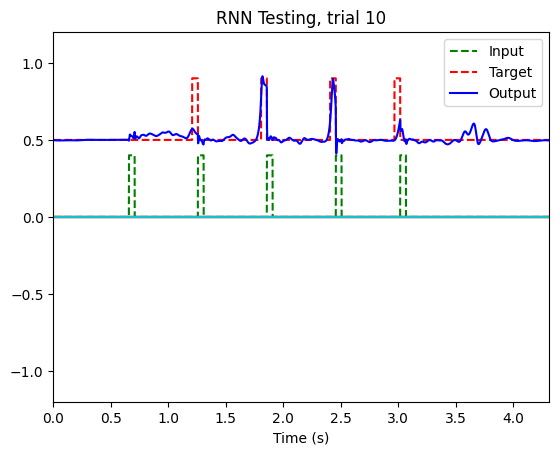

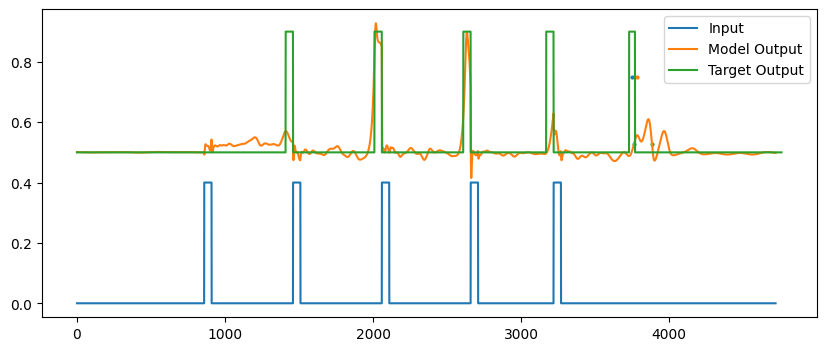

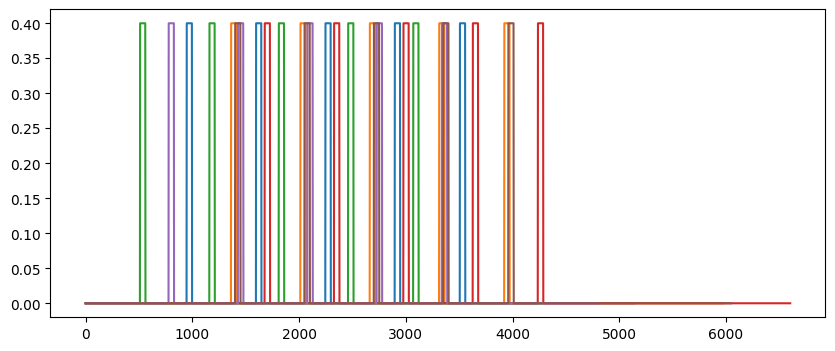

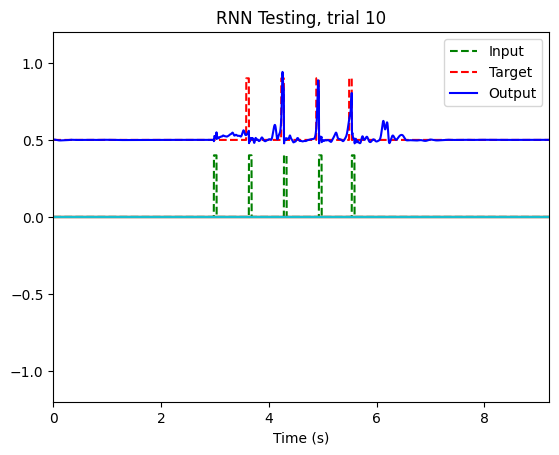

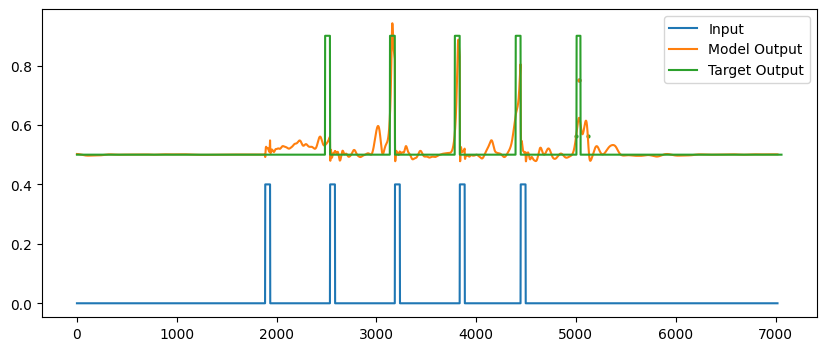

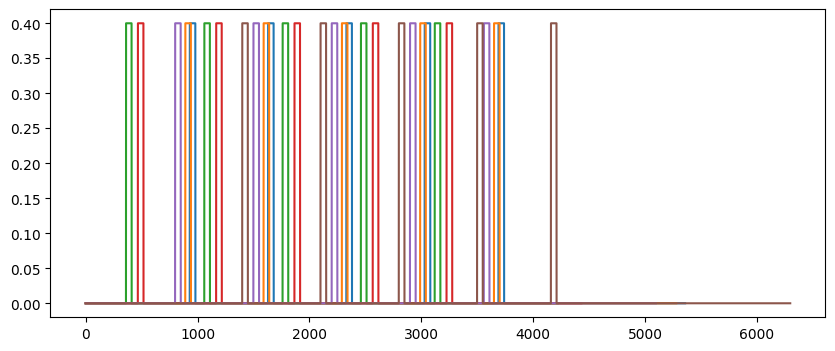

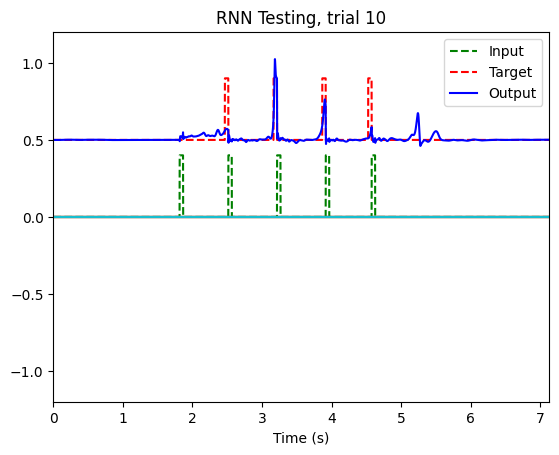

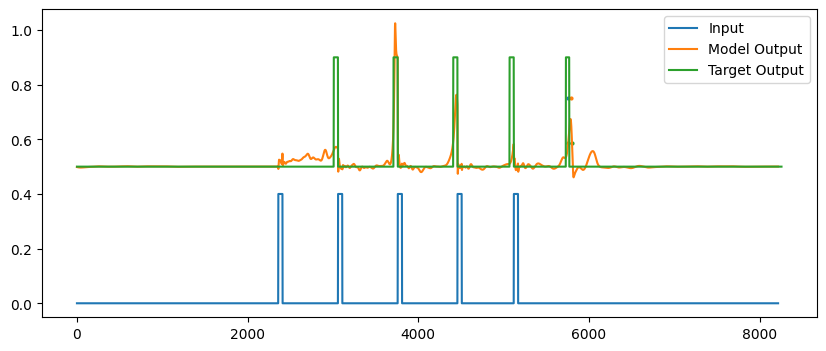

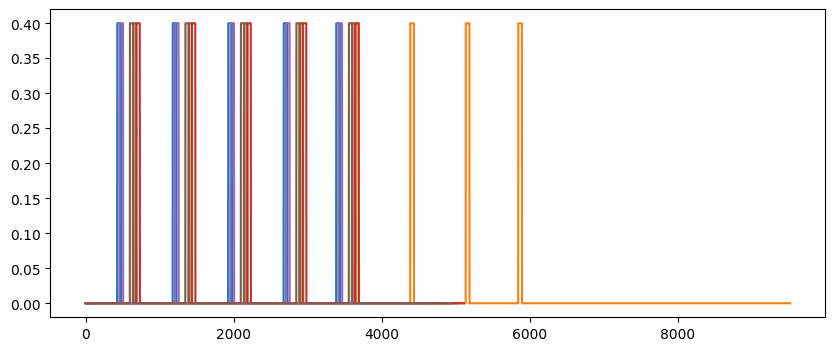

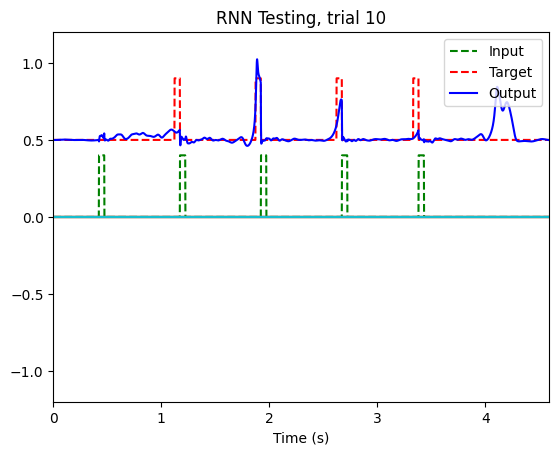

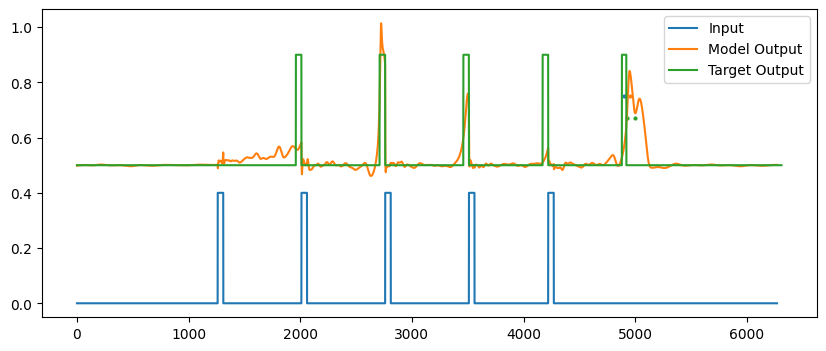

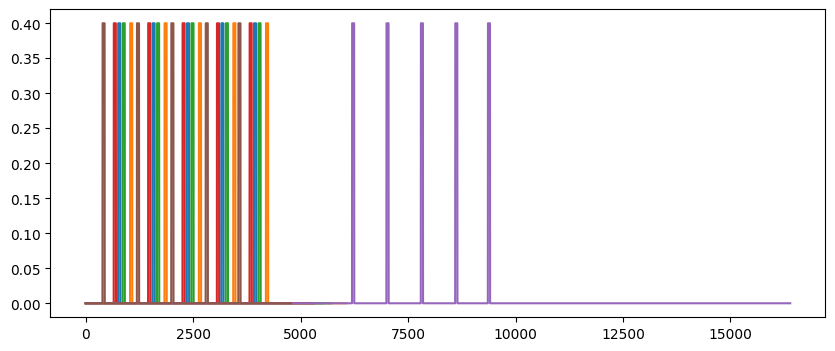

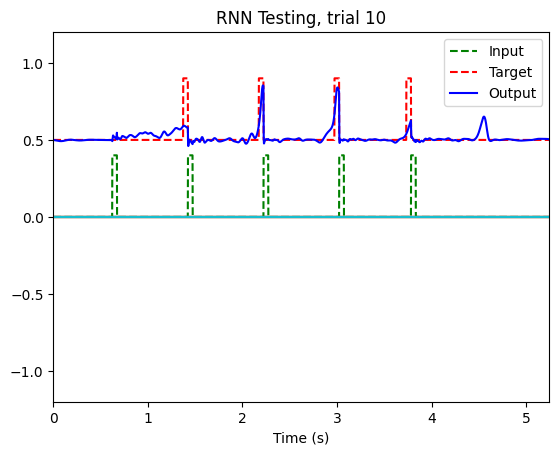

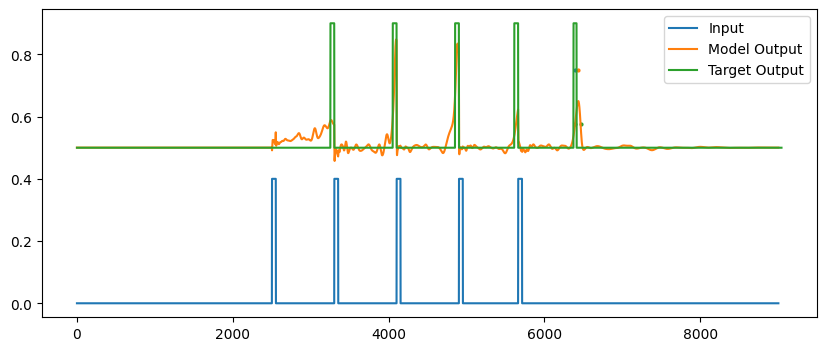

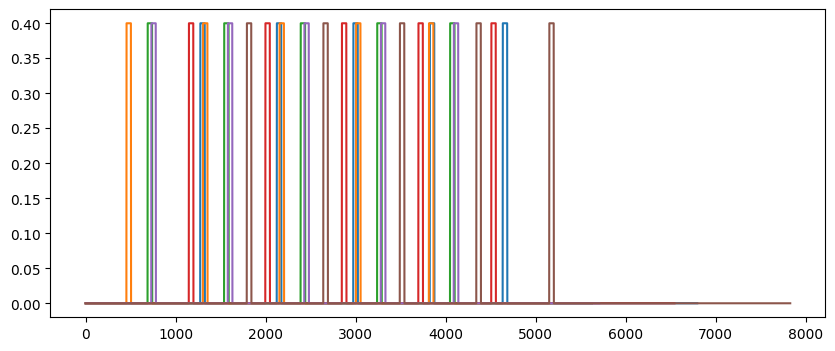

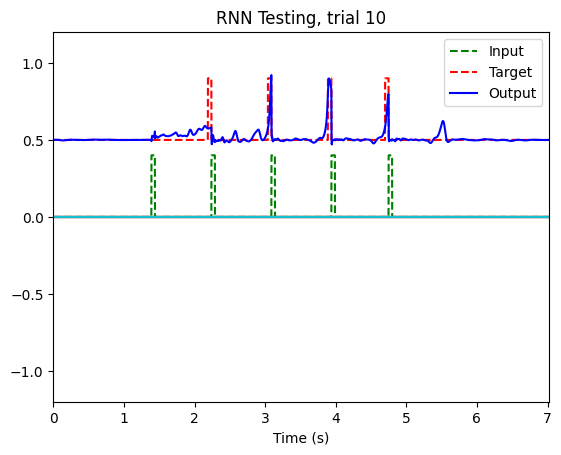

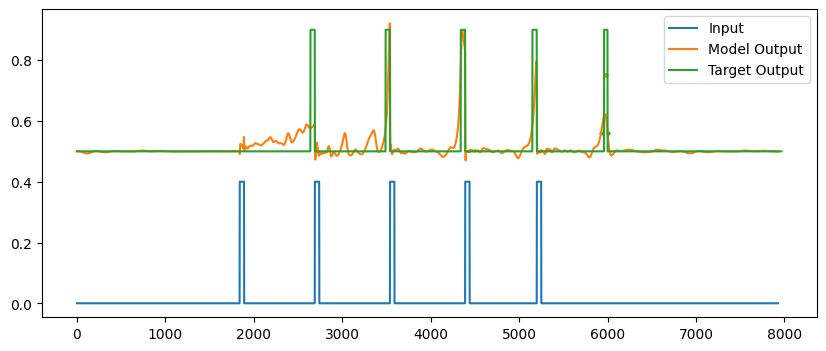

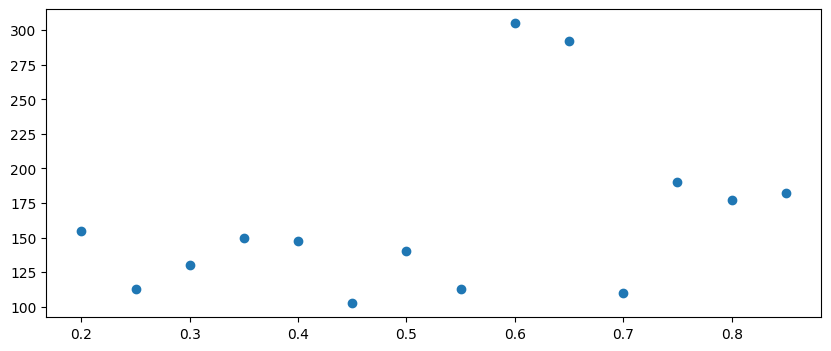

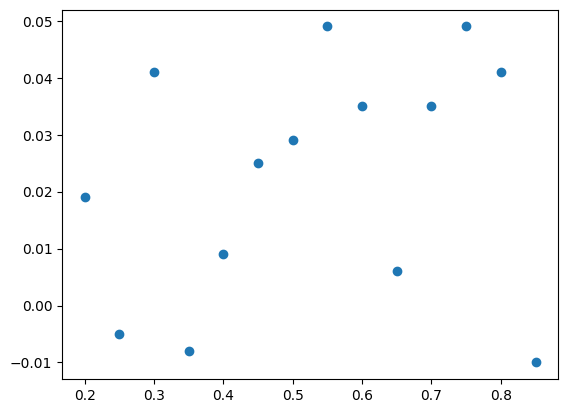

In [69]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure(figsize=(10,4))

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.legend(["Input","Model Output","Target Output"])
    plt.savefig(r'C:\Users\Manav\Documents\GitHub\Full_Force_Pulse_Prediction\Time Variantion\one_pulse_width_early\1x_early_pulse_test_' + str(item)+ '.png', transparent=True)
    plt.figure(figsize=(10,4))
    


plt.scatter(range_array, half_max_width)
all_width.append(half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
all_position.append(position_error)


In [ ]:
plt.scatter(range_array, half_max_width)
all_width.append(half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
all_position.append(position_error)


In [ ]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure(figsize=(10,4))

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.legend(["Input","Model Output","Target Output"])
    plt.savefig(f'pulse_test_{item}.png', transparent=True)
    plt.figure(figsize=(10,4))



plt.scatter(range_array, half_max_width)
all_width.append(half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
all_position.append(position_error)


Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.019 seconds late
The width of the predicted pulse at half-max is 155.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.004 seconds early
The width of the predicted pulse at half-max is 262.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.041 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.008 seconds early
The width of the predicted pulse at half-max is 150.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.009000000000000001 seconds late
The width of the predicted pulse at half-max is 147.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.025 seconds late
The width of the predicted pulse at half-max is 

C:\Users\Manav\AppData\Local\Temp\ipykernel_8840\1535192864.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,4))


....
Testing: 10 trials
..........
The predicted pulse peak is 0.049 seconds late
The width of the predicted pulse at half-max is 112.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.035 seconds late
The width of the predicted pulse at half-max is 305.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.006 seconds late
The width of the predicted pulse at half-max is 292.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.036000000000000004 seconds late
The width of the predicted pulse at half-max is 110.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.049 seconds late
The width of the predicted pulse at half-max is 190.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.041 seconds late
The width of the predicted pulse at half-max is 177.5% the size

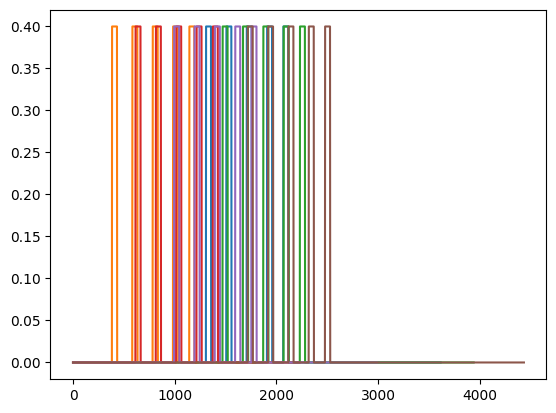

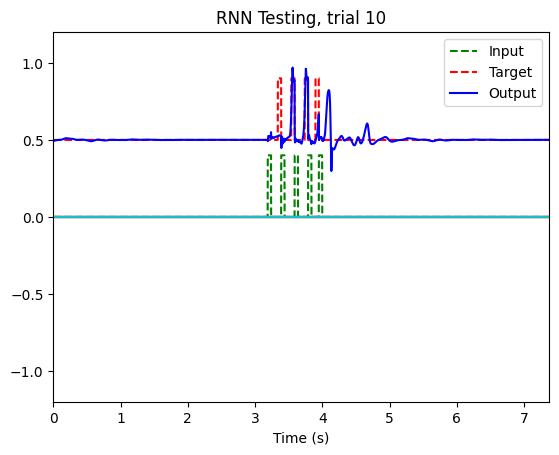

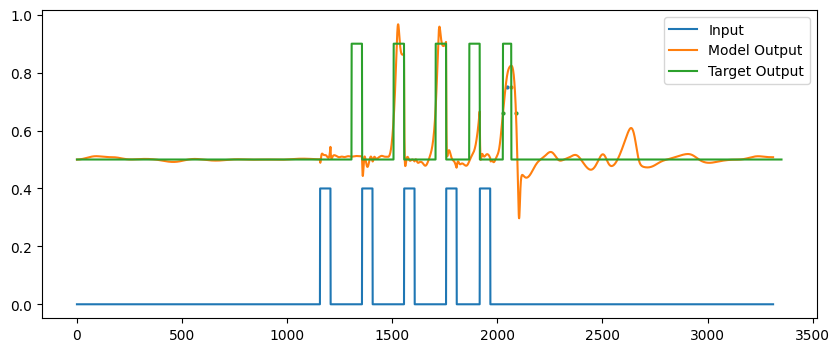

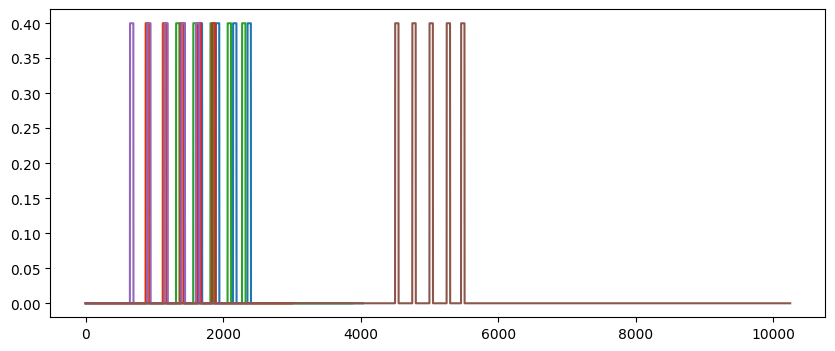

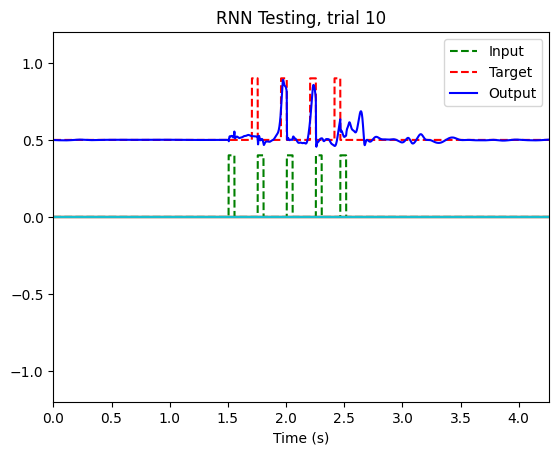

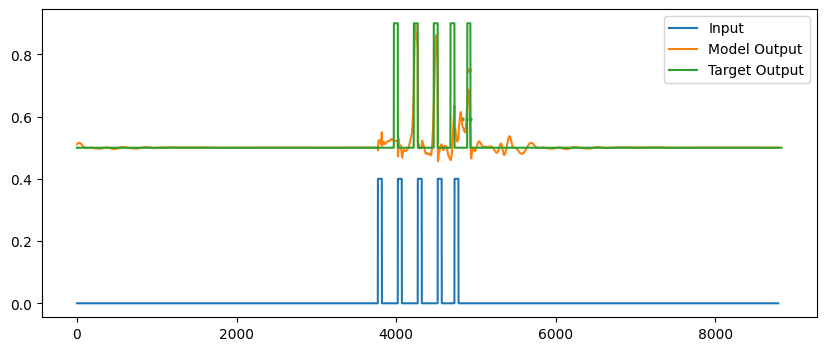

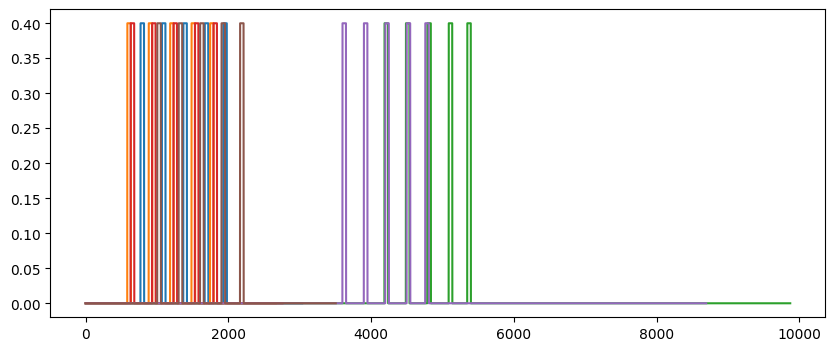

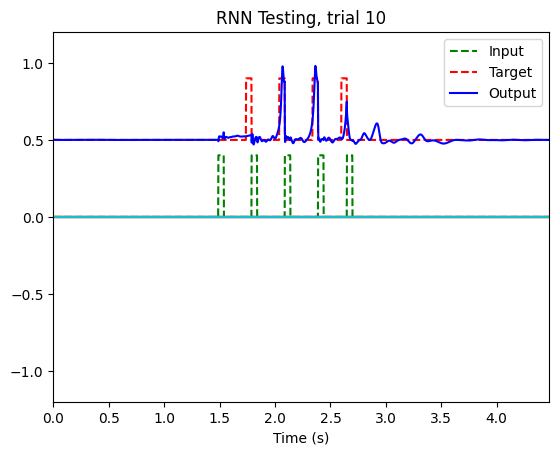

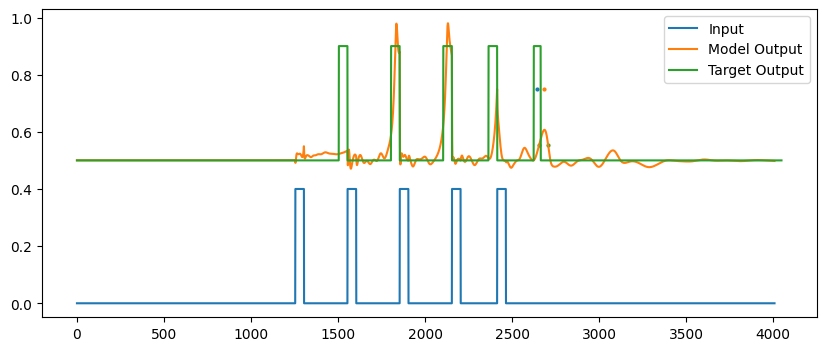

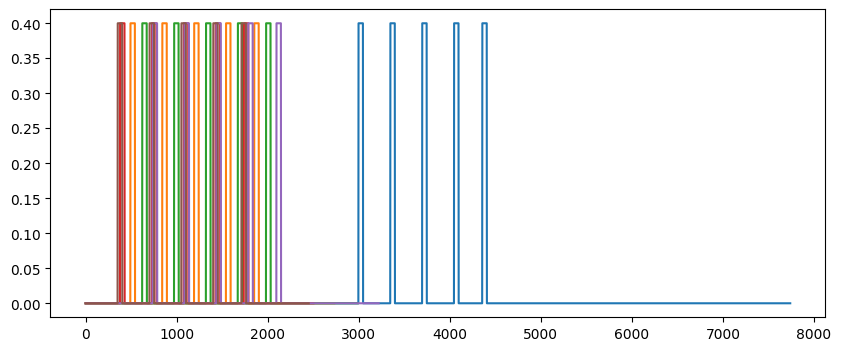

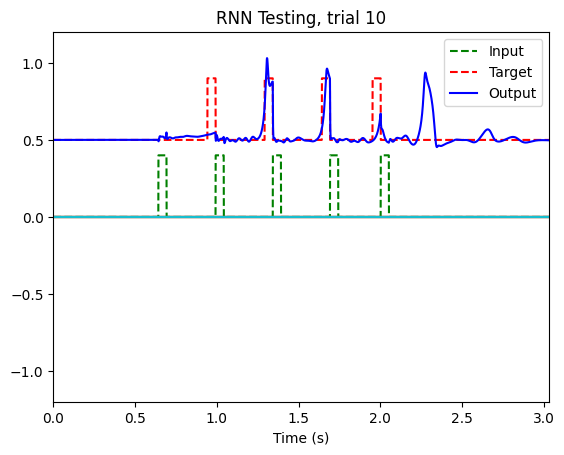

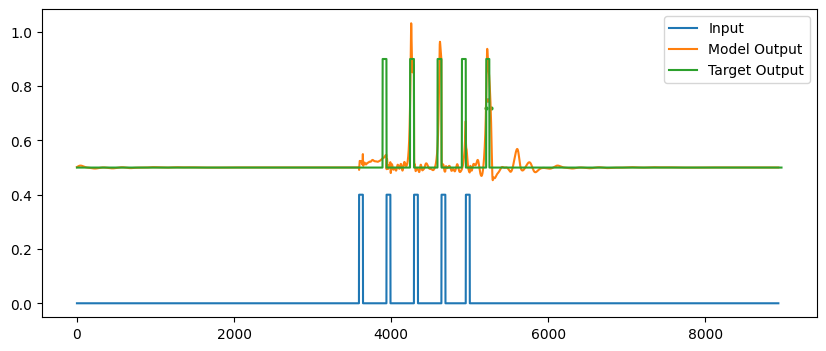

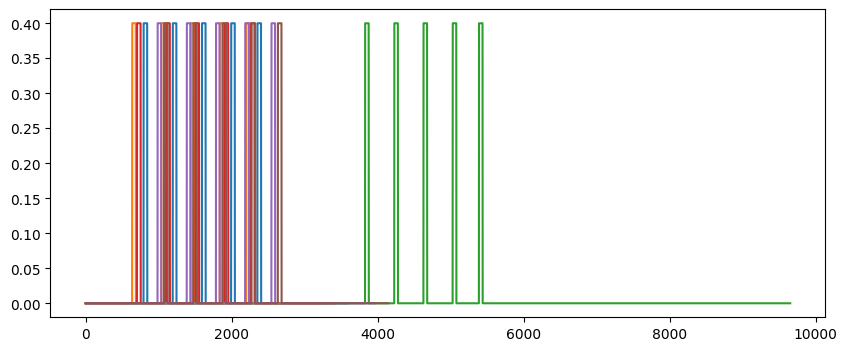

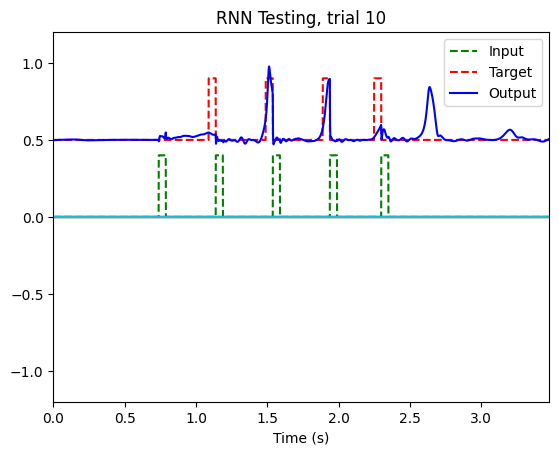

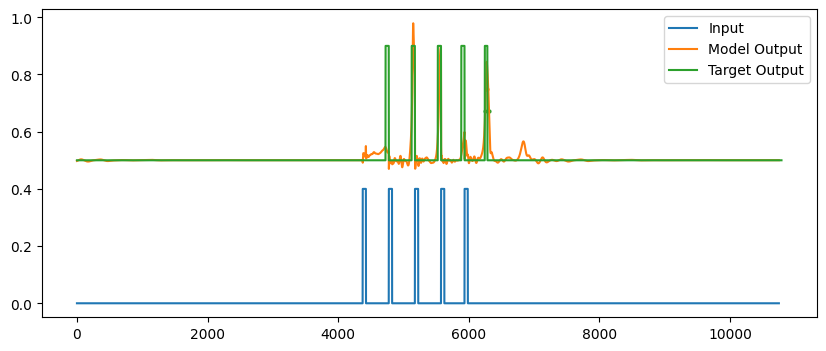

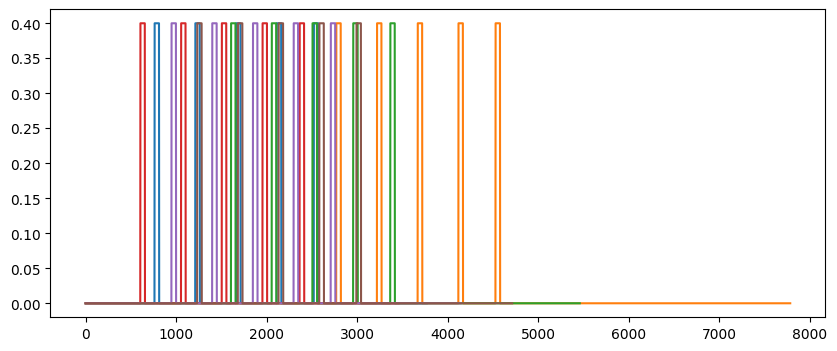

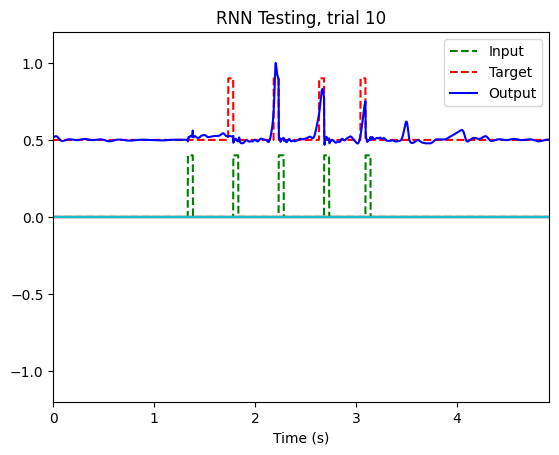

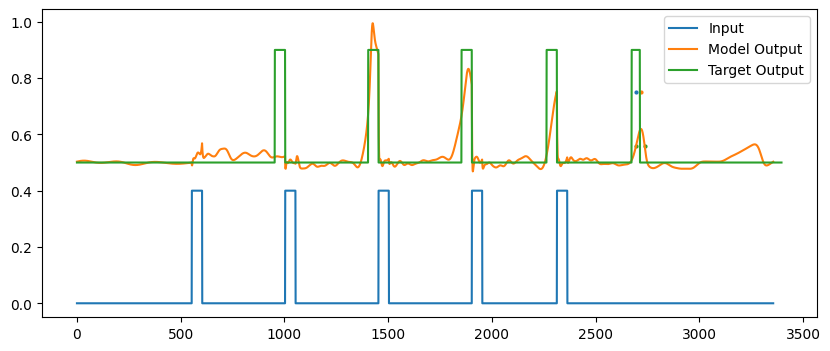

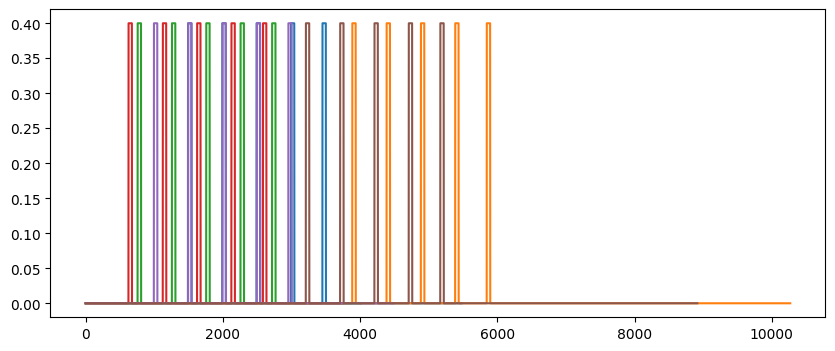

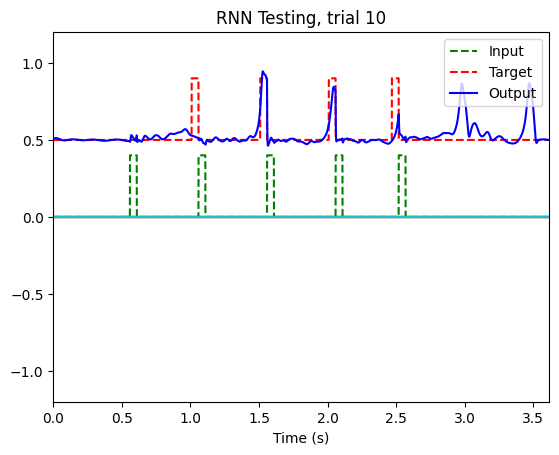

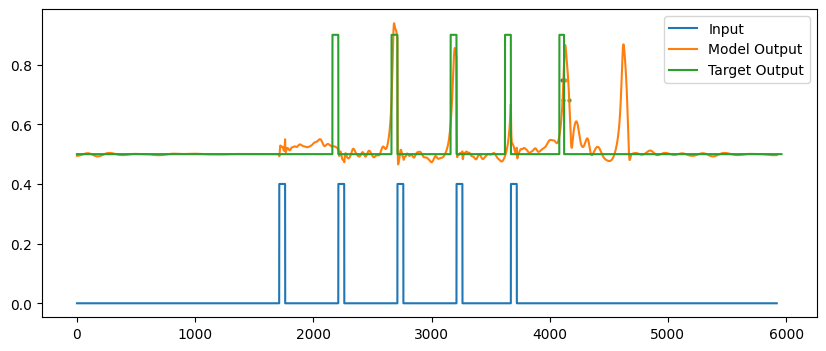

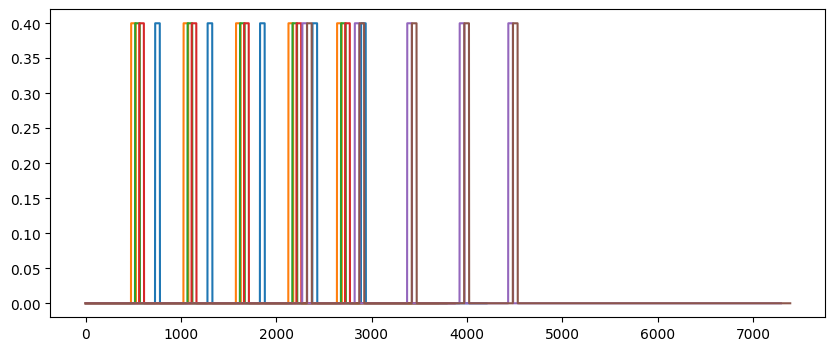

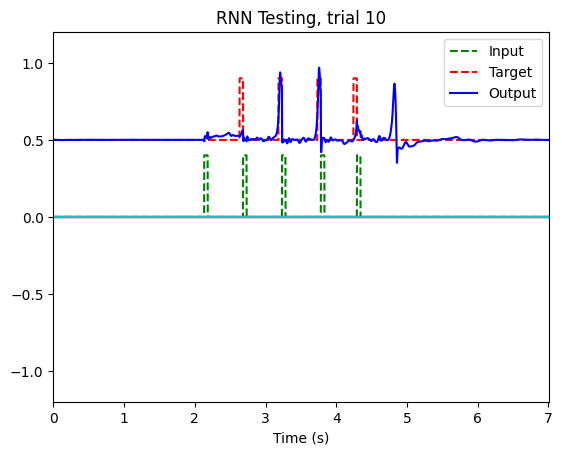

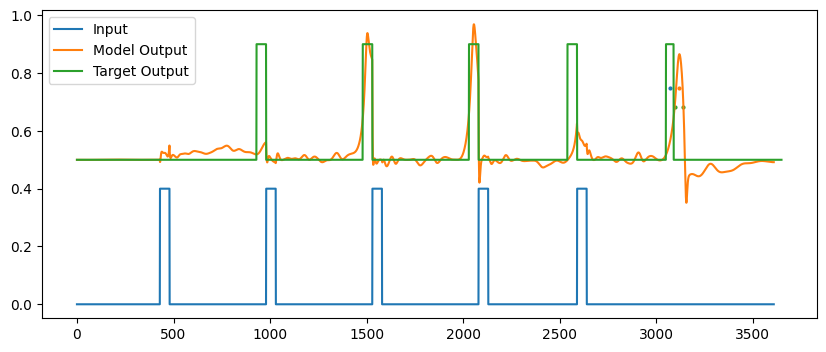

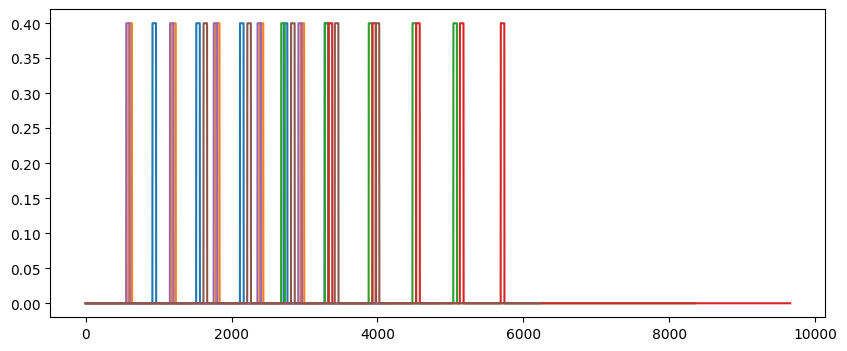

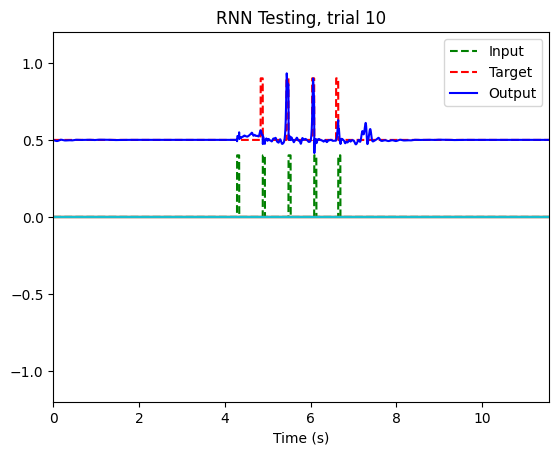

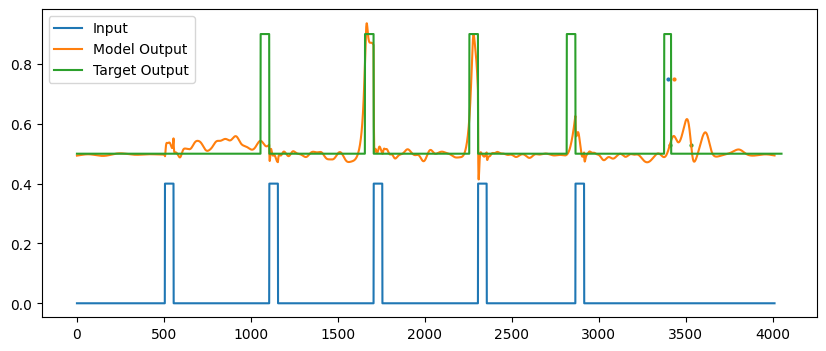

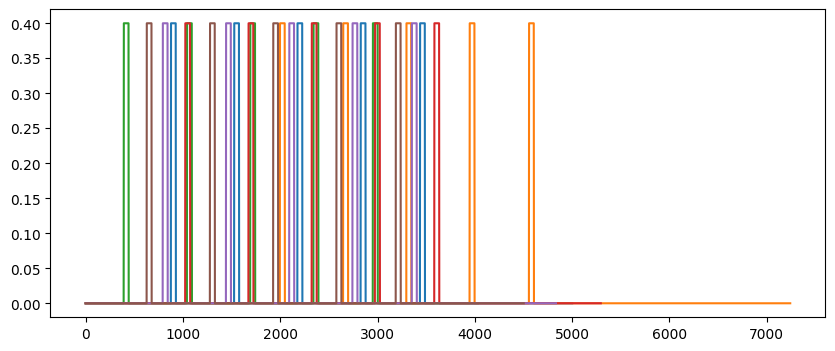

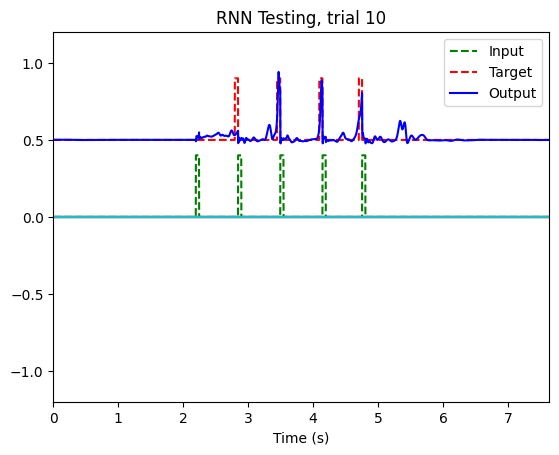

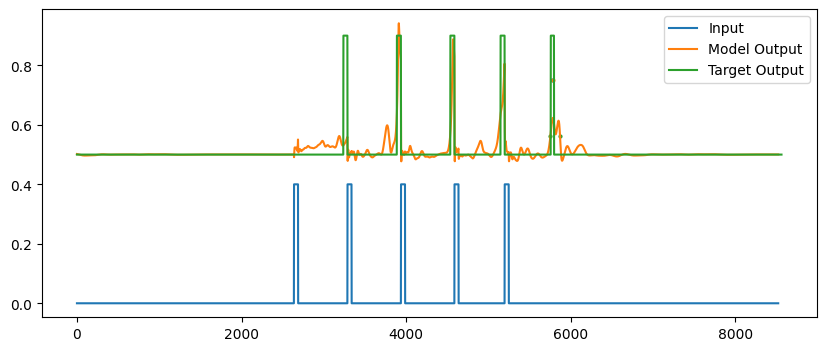

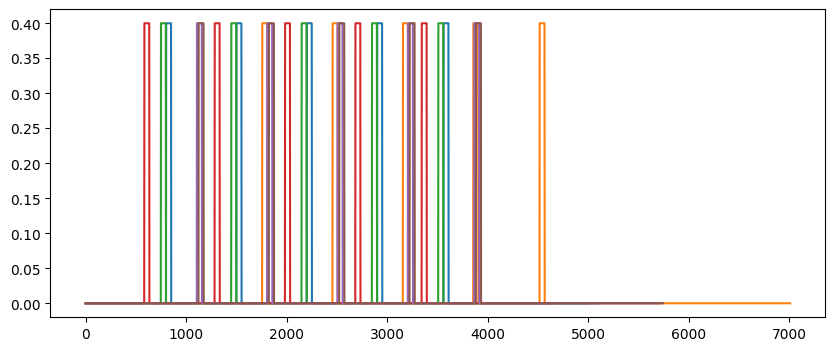

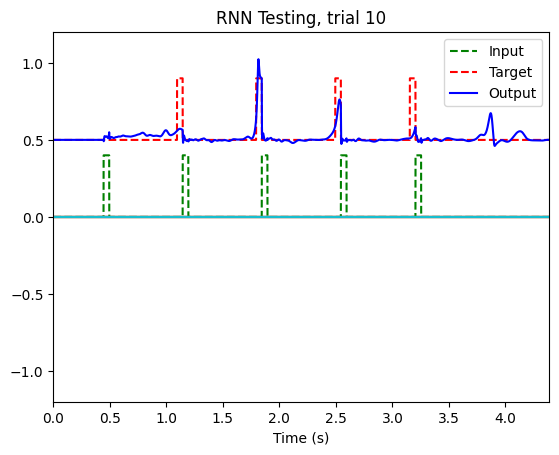

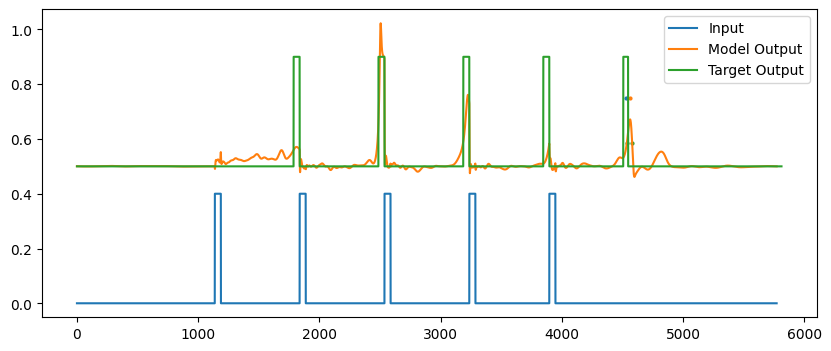

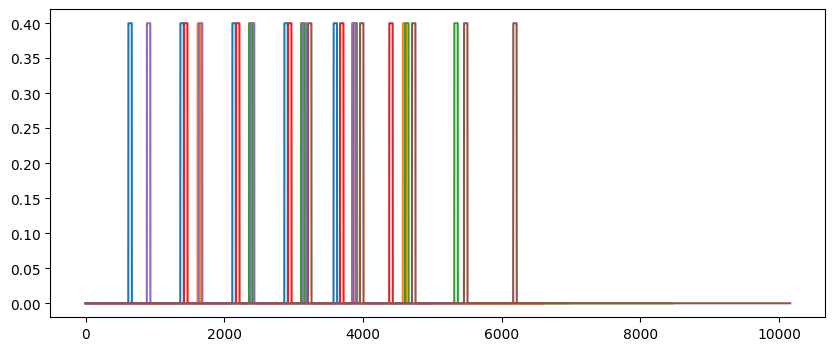

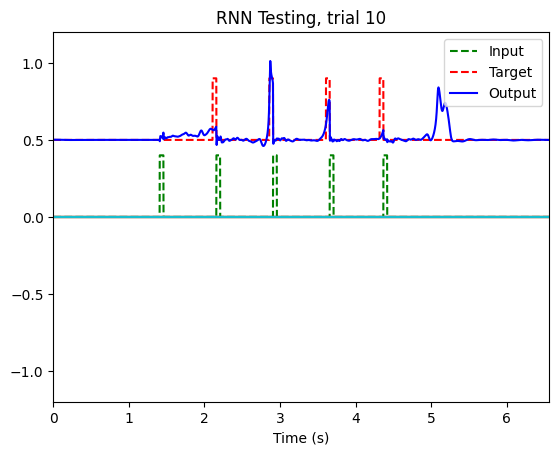

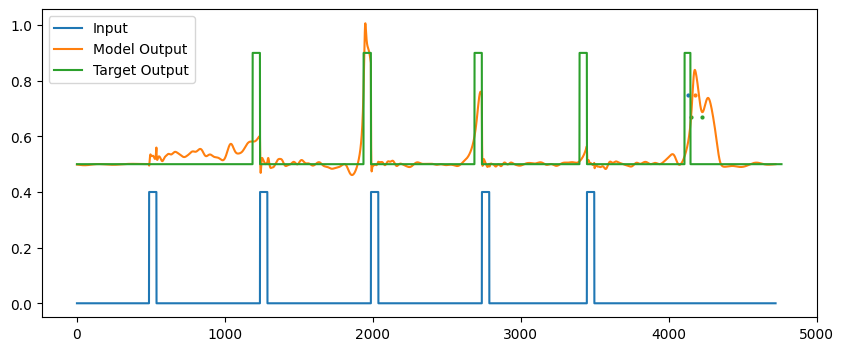

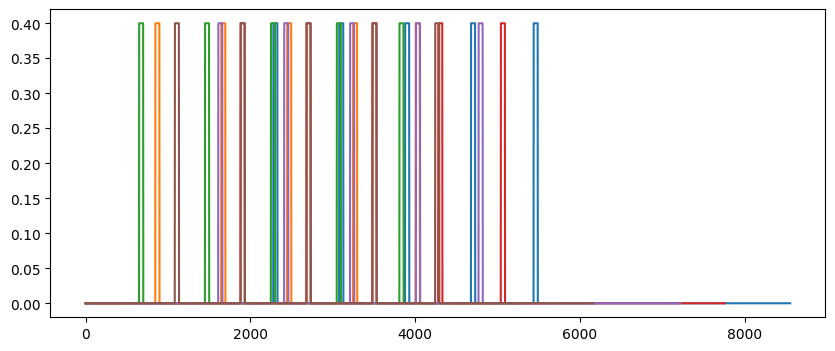

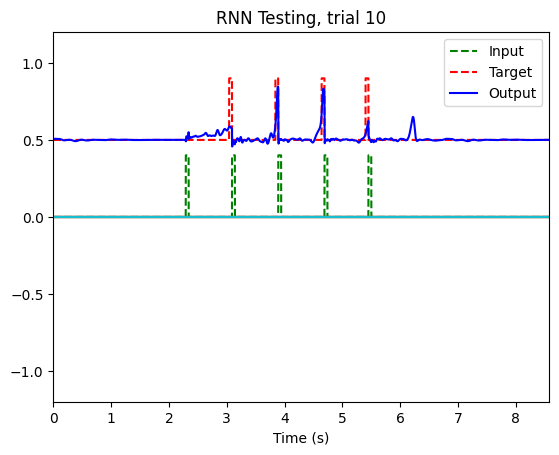

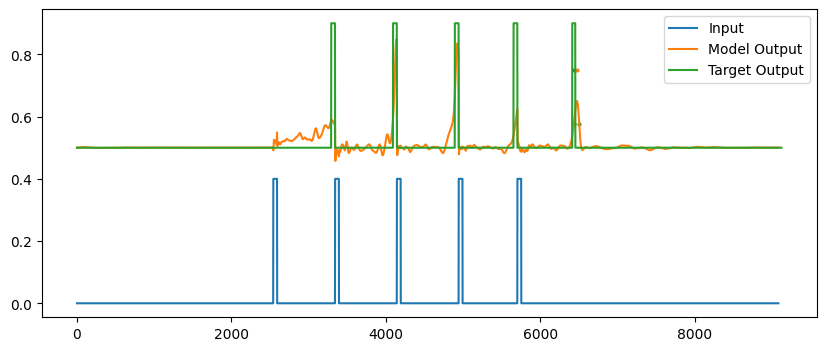

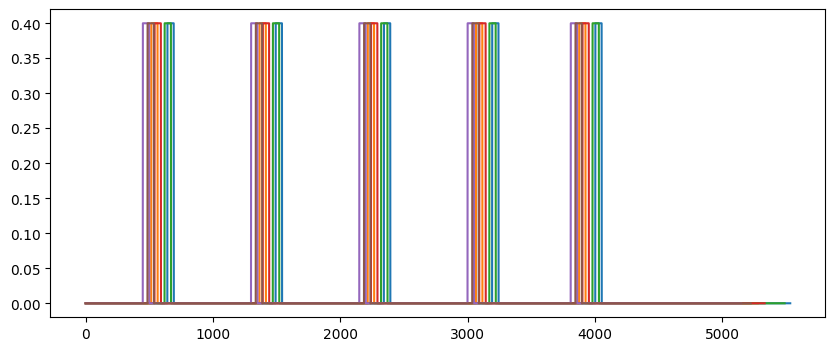

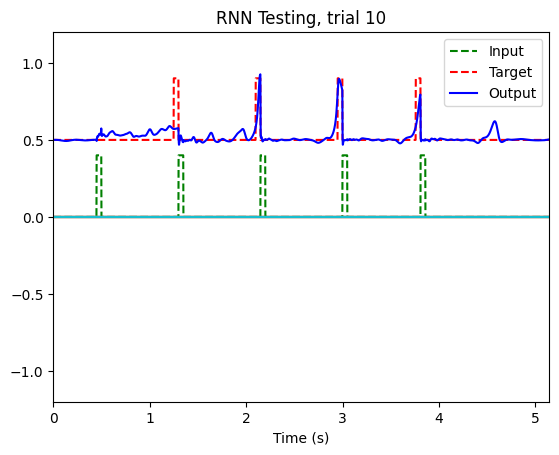

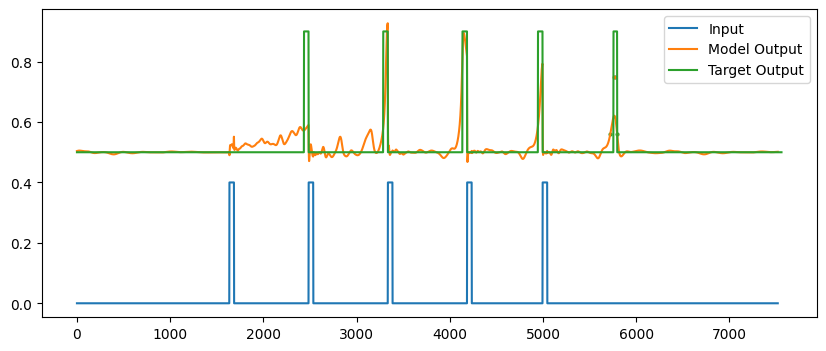

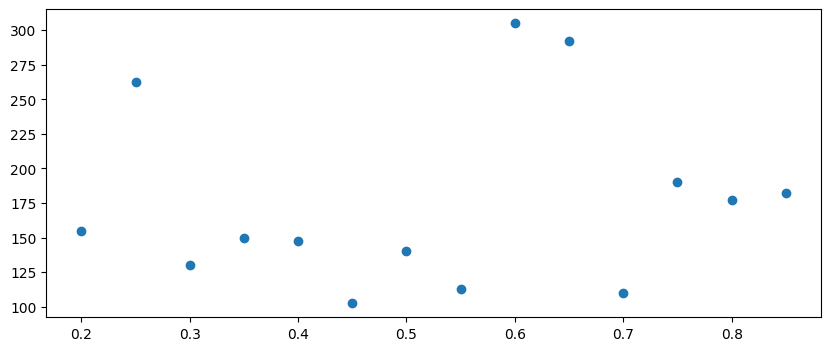

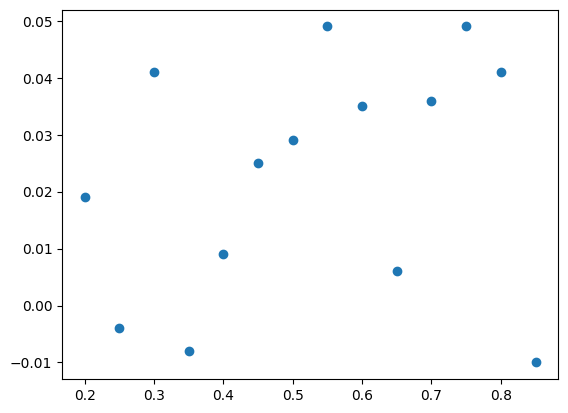

In [8]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure(figsize=(10,4))

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.legend(["Input","Model Output","Target Output"])
    plt.savefig(f'pulse_test_{item}.png', transparent=True)
    plt.figure(figsize=(10,4))



plt.scatter(range_array, half_max_width)
all_width.append(half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
all_position.append(position_error)


Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.013000000000000001 seconds late
The width of the predicted pulse at half-max is 110.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.031 seconds late
The width of the predicted pulse at half-max is 215.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.111 seconds early
The width of the predicted pulse at half-max is 280.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.0 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.028 seconds late
The width of the predicted pulse at half-max is 157.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.007 seconds early
The width of the predicted pulse at half-max is 18

/var/folders/sm/06fq8qt553j0wpvnh8x6ys3h0000gn/T/ipykernel_62513/1535192864.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,4))


....
Testing: 10 trials
..........
The predicted pulse peak is 0.027 seconds late
The width of the predicted pulse at half-max is 180.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.079 seconds late
The width of the predicted pulse at half-max is 282.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.051000000000000004 seconds late
The width of the predicted pulse at half-max is 160.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.029 seconds late
The width of the predicted pulse at half-max is 127.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.05 seconds late
The width of the predicted pulse at half-max is 172.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.014 seconds early
The width of the predicted pulse at half-max is 167.5% the size

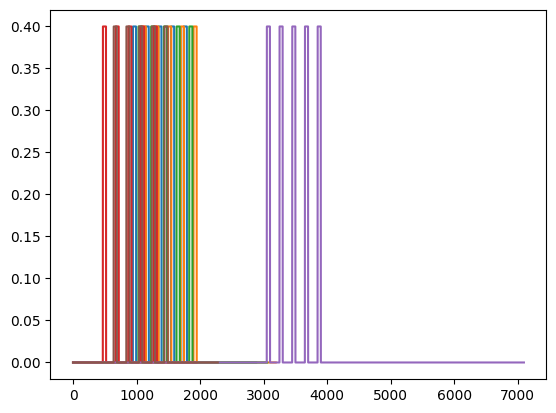

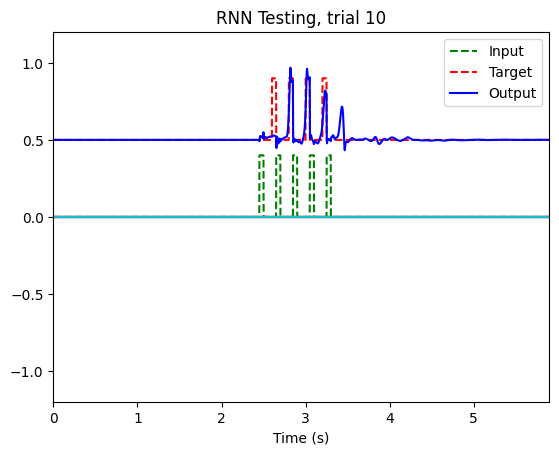

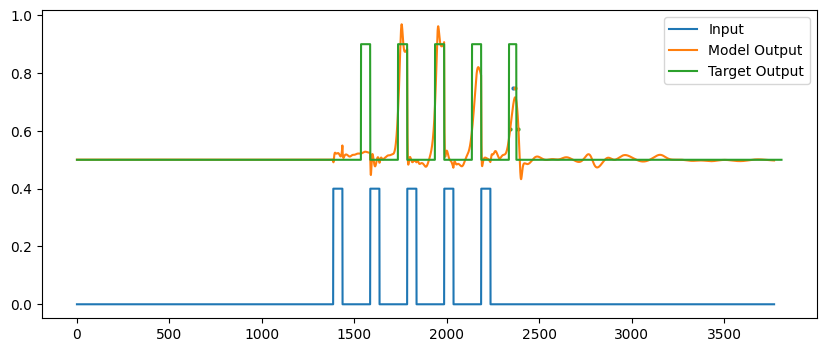

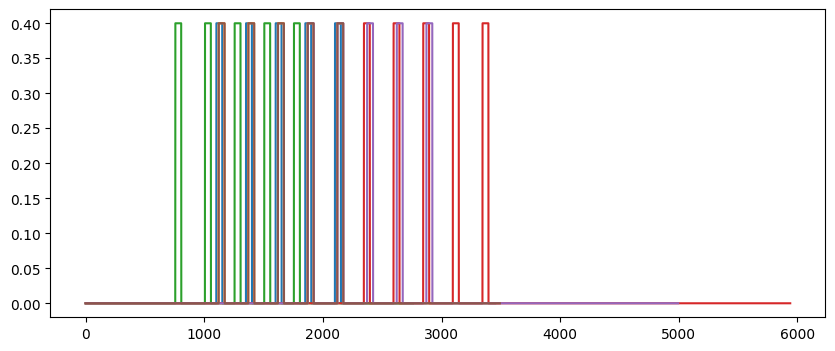

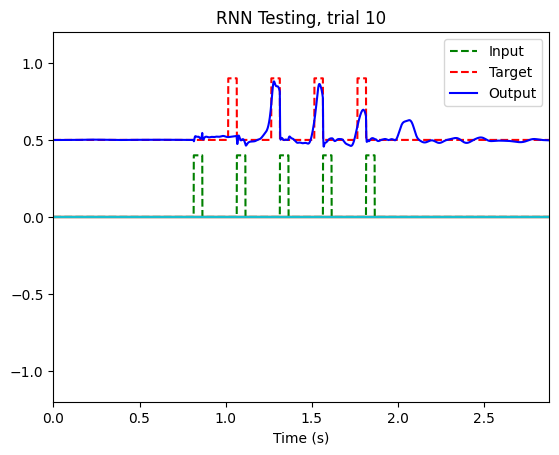

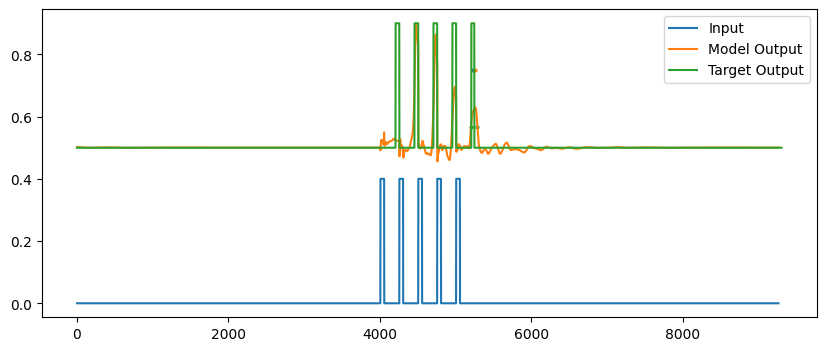

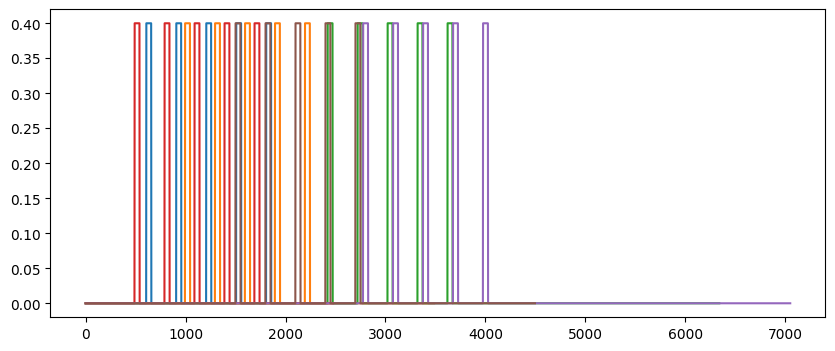

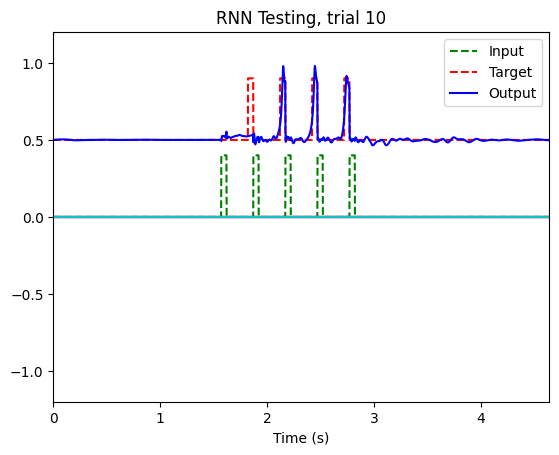

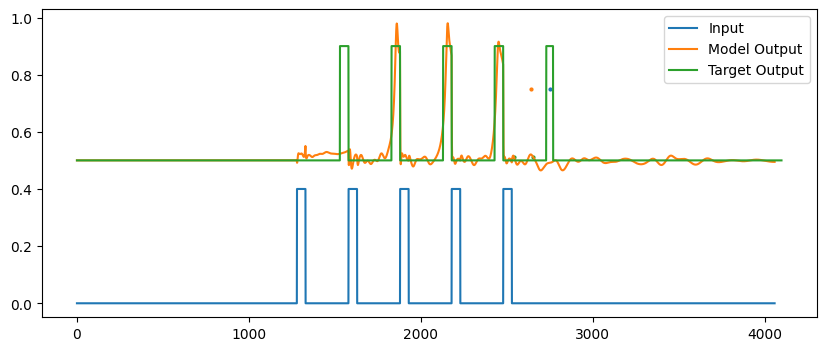

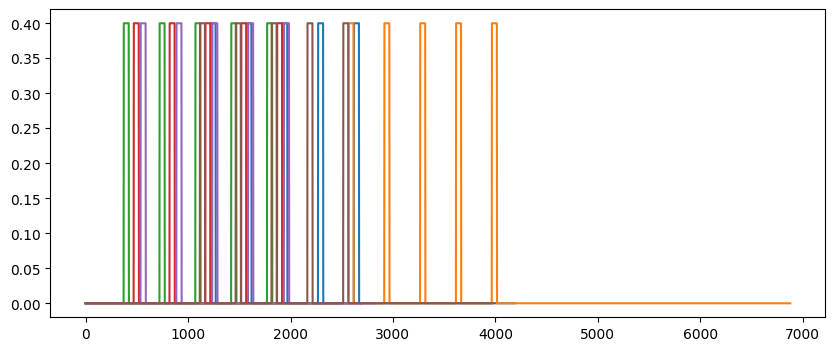

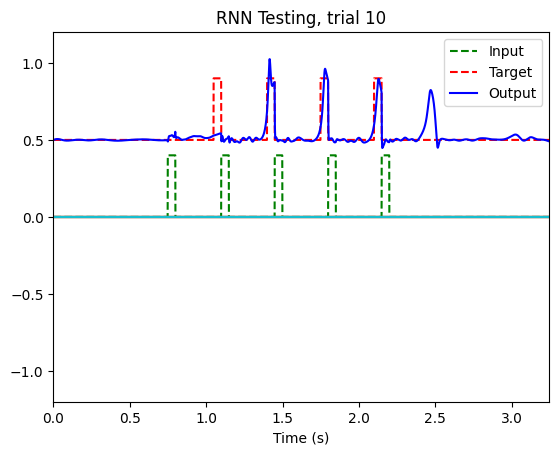

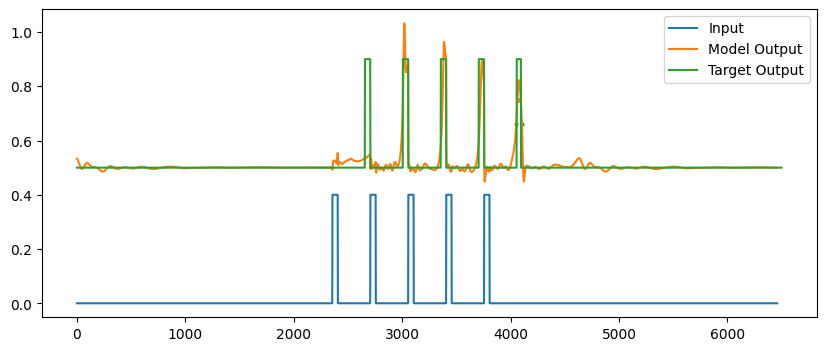

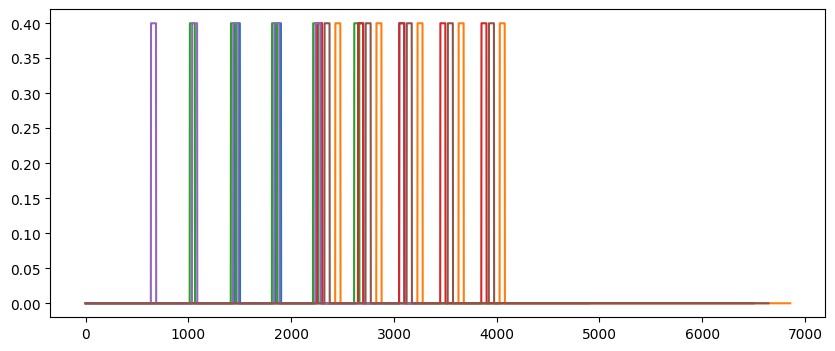

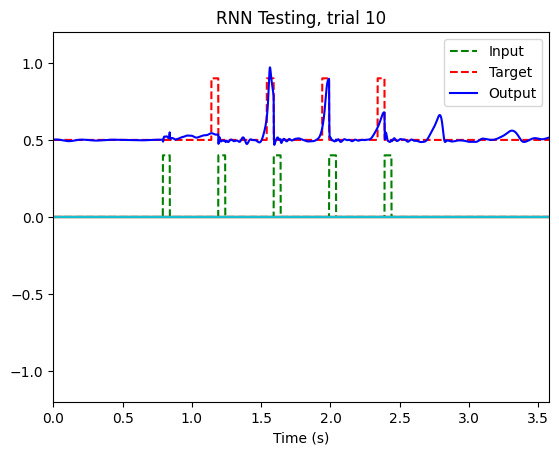

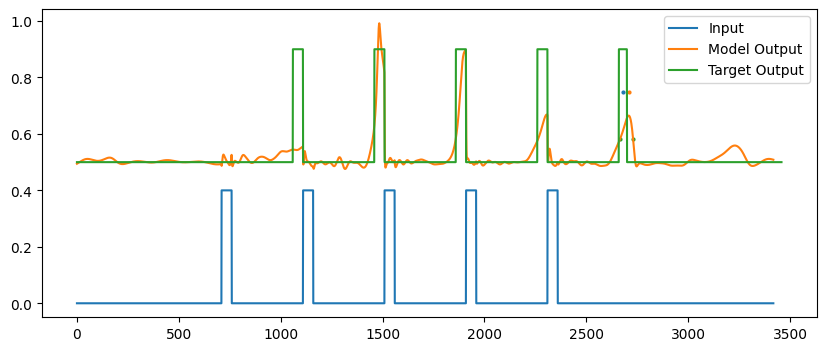

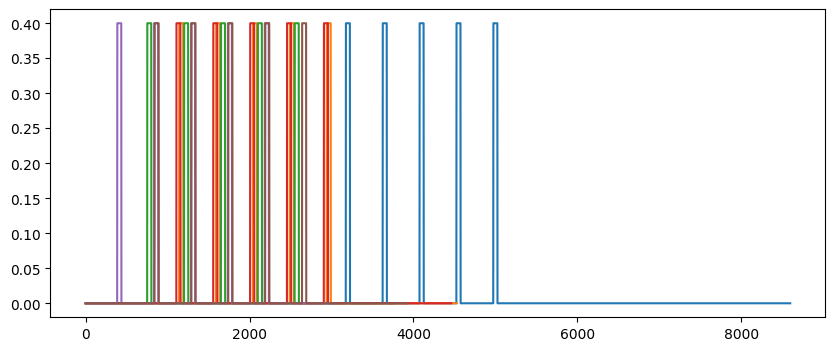

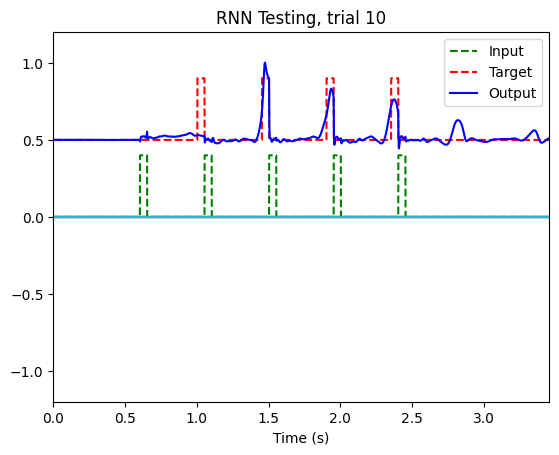

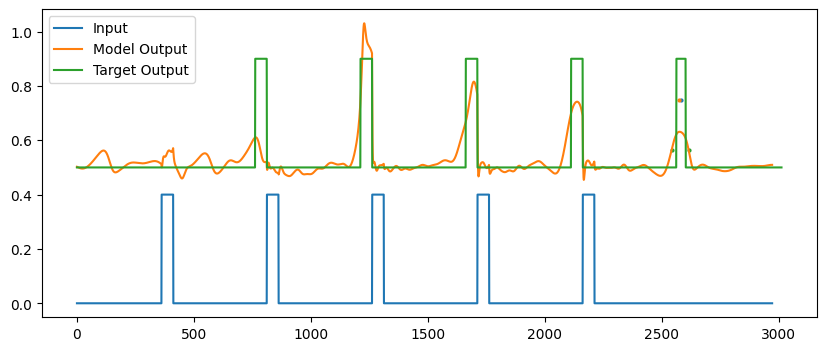

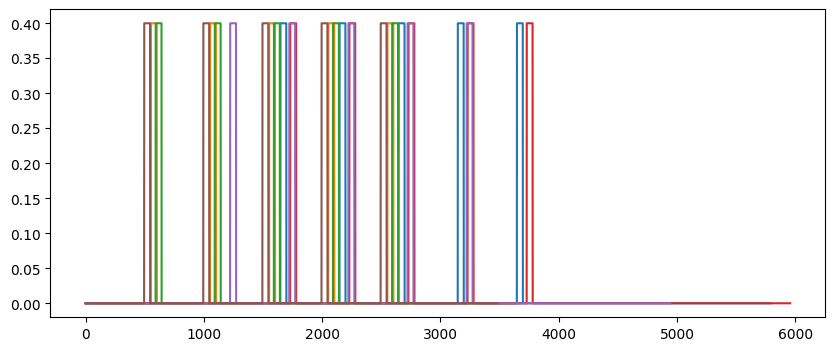

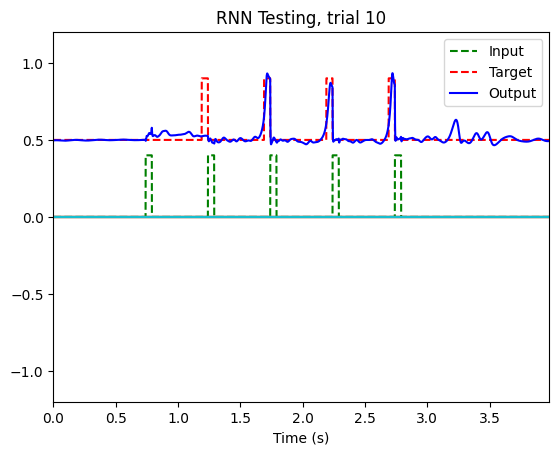

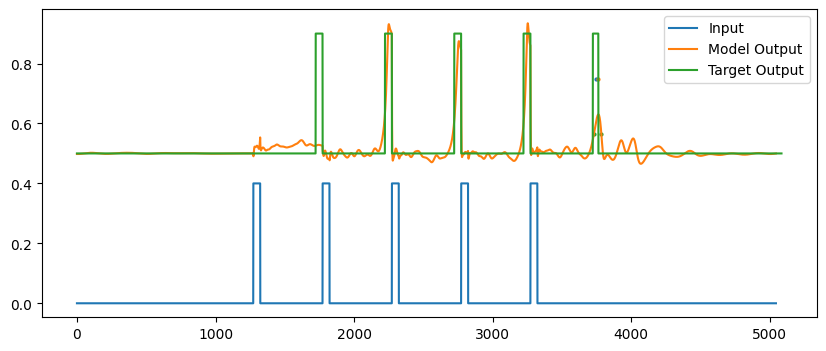

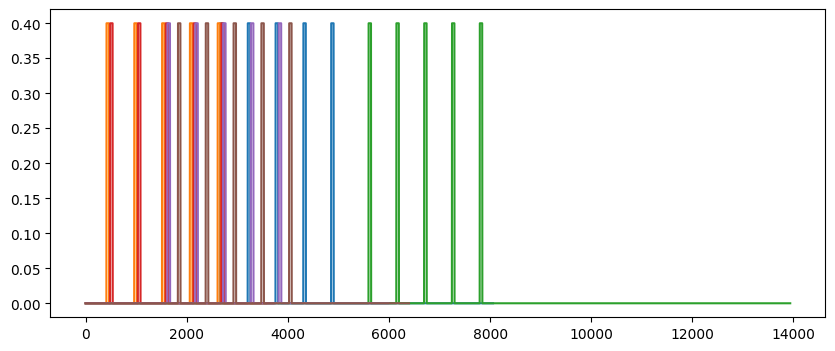

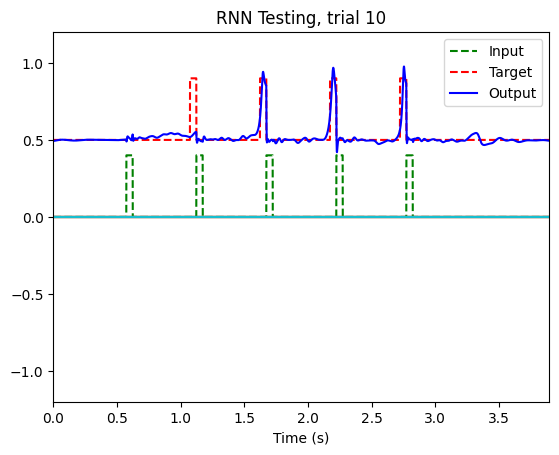

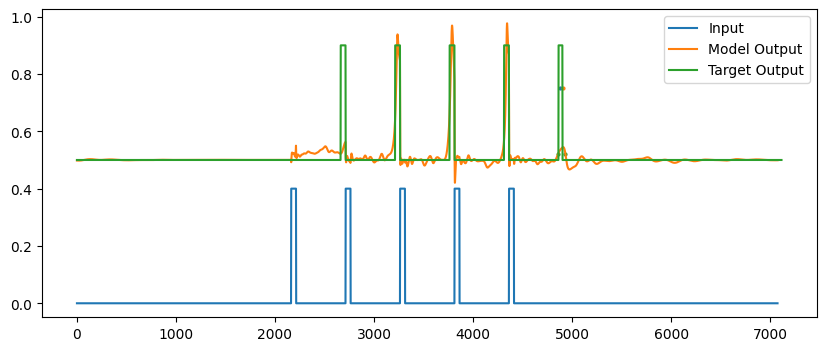

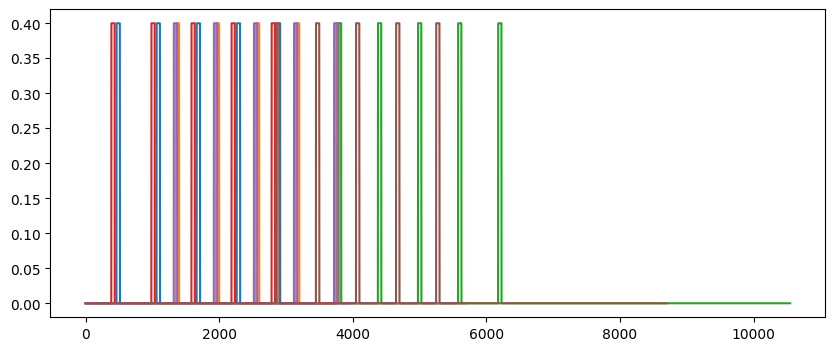

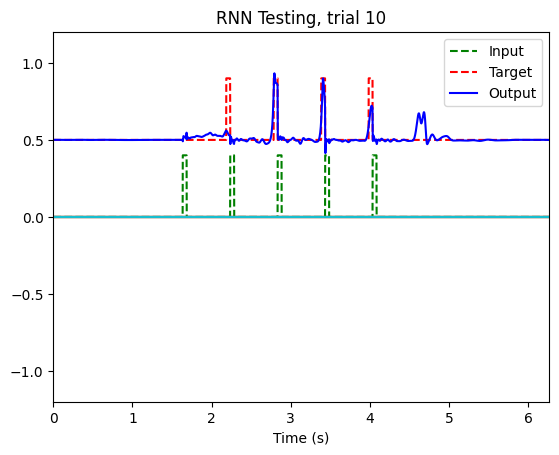

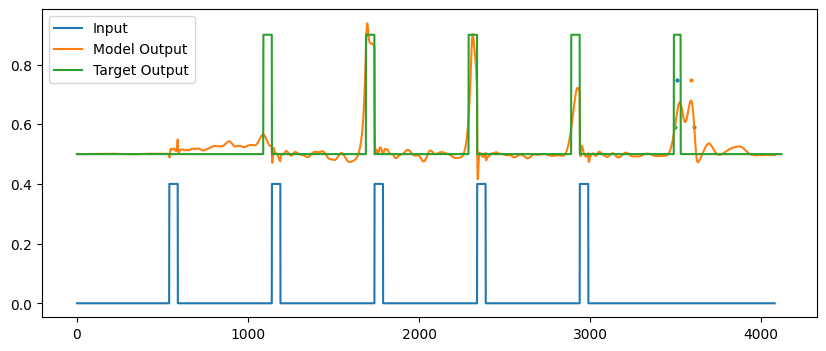

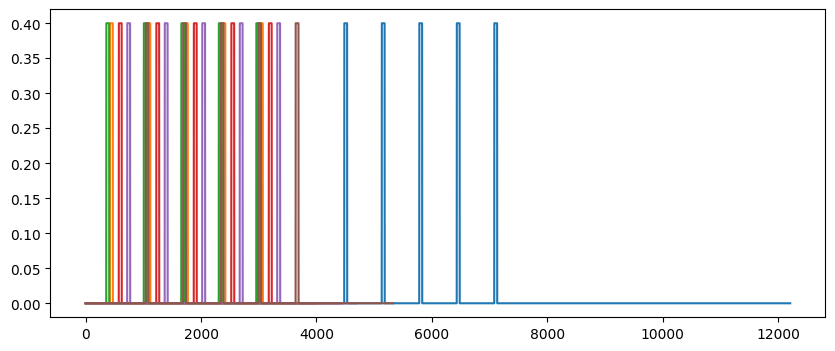

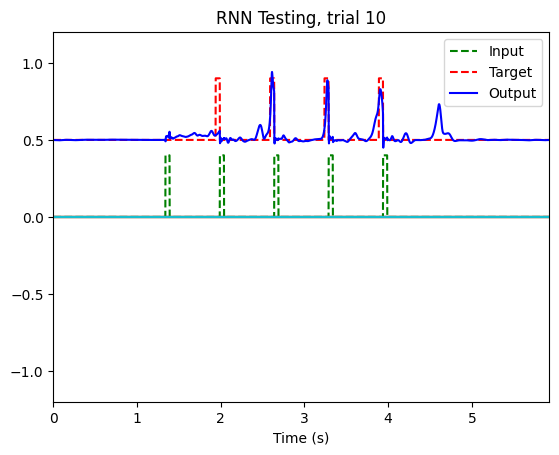

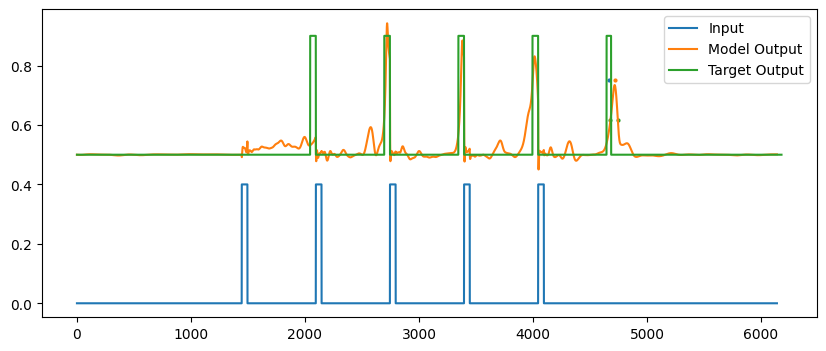

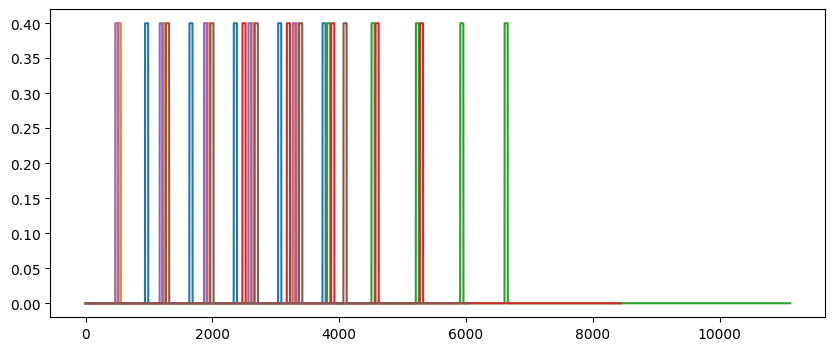

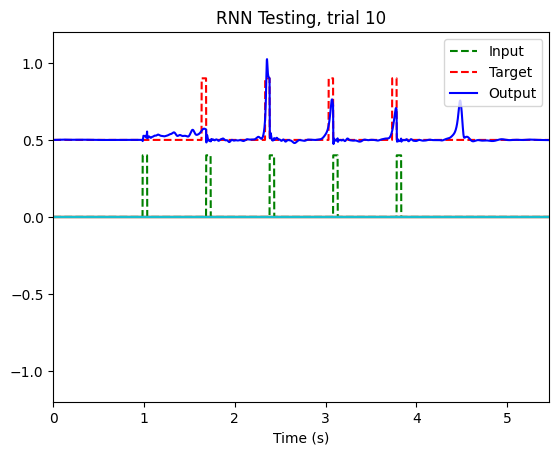

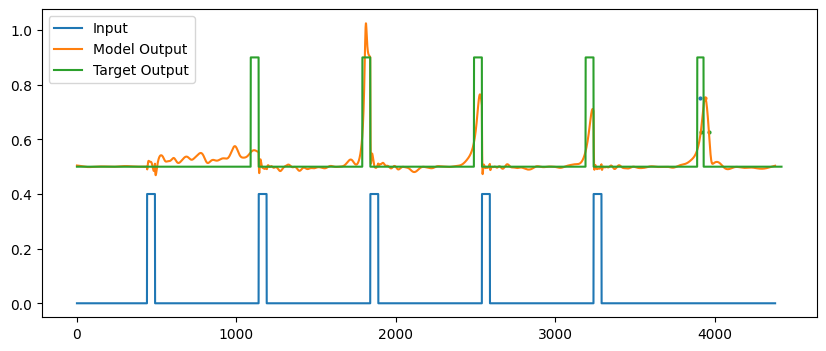

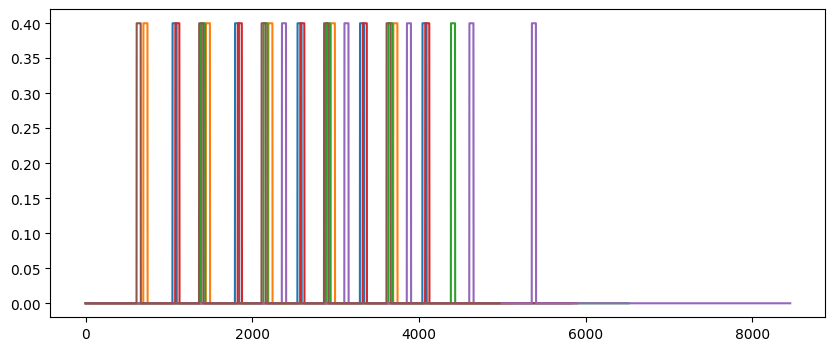

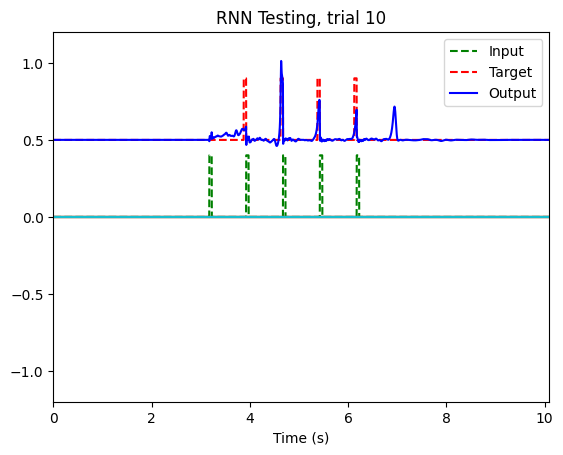

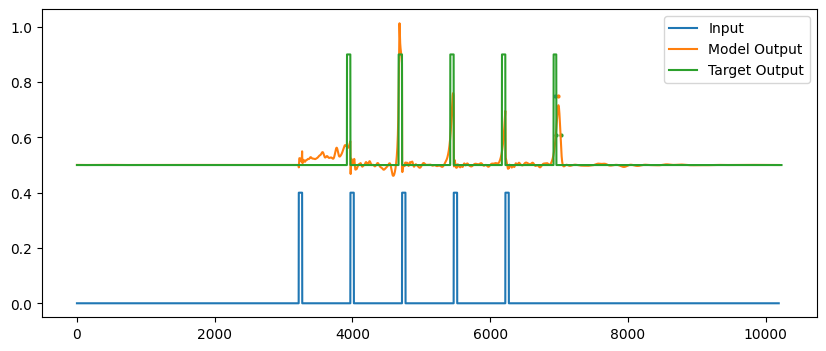

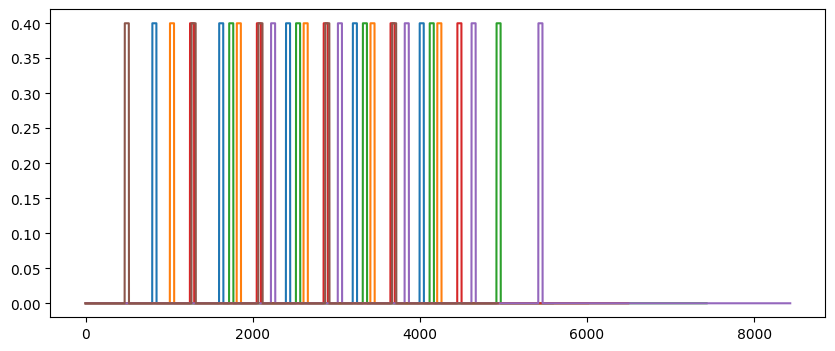

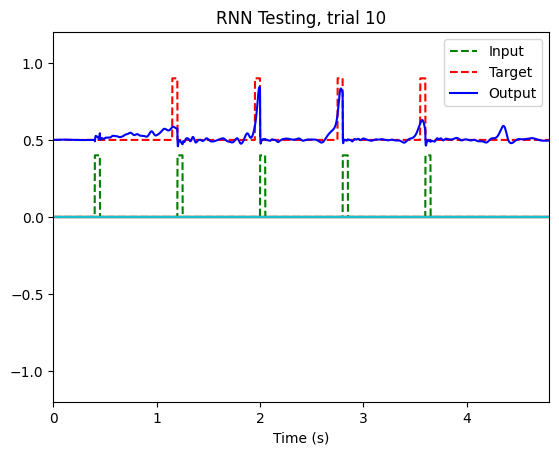

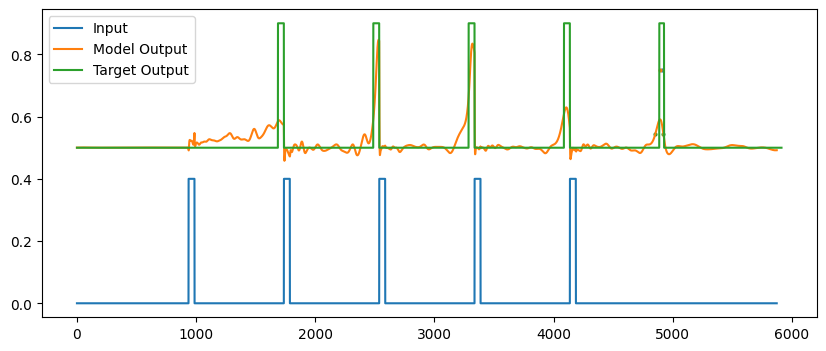

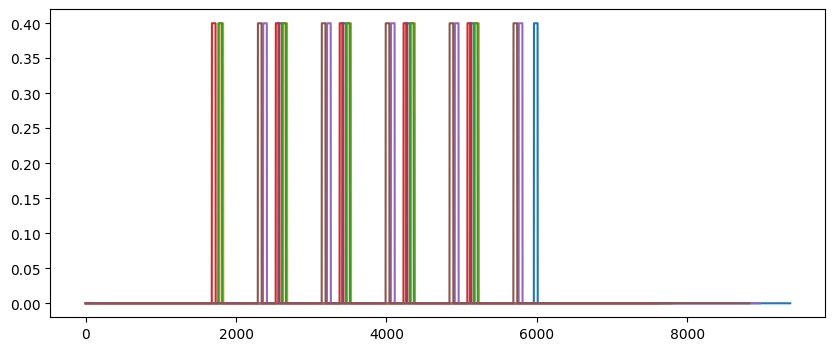

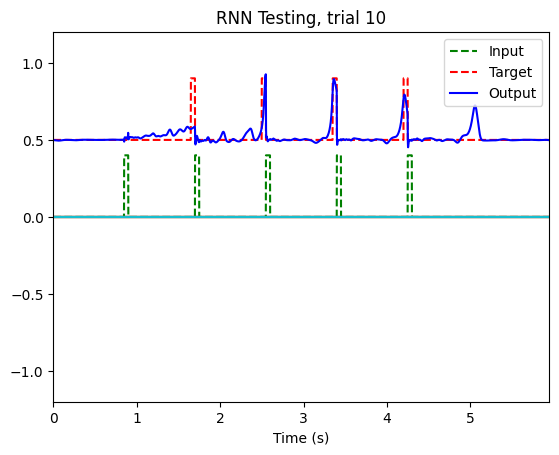

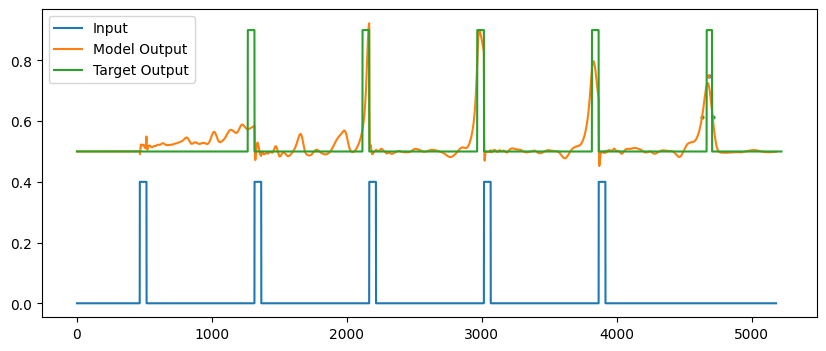

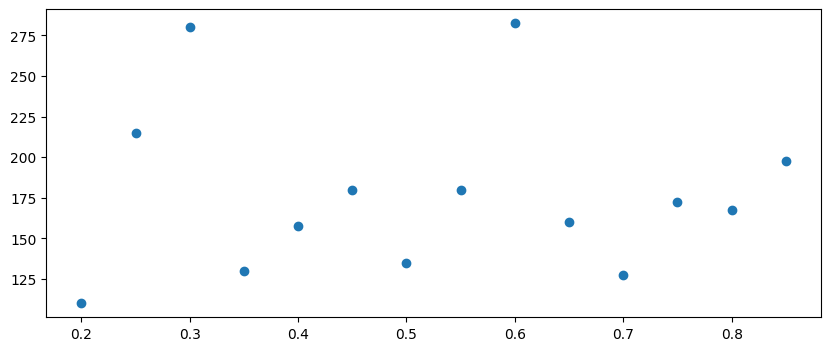

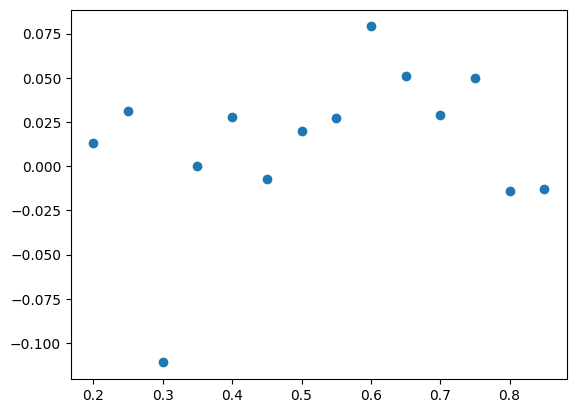

In [7]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure(figsize=(10,4))

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.legend(["Input","Model Output","Target Output"])
    plt.savefig(f'pulse_test_{item}.png', transparent=True)
    plt.figure(figsize=(10,4))



plt.scatter(range_array, half_max_width)
all_width.append(half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
all_position.append(position_error)


(7, 14)
[[0.031, 0.005, -0.116, -0.016, -0.003, 0.066, -0.011, 0.026000000000000002, -0.002, 0.079, -0.036000000000000004, 0.024, 0.045, 0.025], [0.019, -0.003, 0.041, -0.008, 0.008, 0.025, 0.029, 0.049, 0.035, 0.006, 0.035, 0.049, 0.041, -0.01], [0.009000000000000001, 0.026000000000000002, -0.091, -0.019, 0.002, 0.006, 0.033, 0.03, 0.079, 0.077, 0.035, 0.053, 0.008, -0.015], [0.013000000000000001, 0.031, -0.111, 0.001, 0.028, -0.005, 0.02, 0.027, 0.079, 0.05, 0.03, 0.05, -0.014, -0.013000000000000001], [0.024, -0.035, 0.027, 0.004, 0.011, -0.007, -0.003, 0.032, 0.079, 0.003, 0.032, 0.023, -0.028, -0.028], [0.038, -0.06, 0.014, 0.067, -0.007, 0.025, -0.029, 0.015, 0.078, -0.02, 0.037, -0.001, -0.029, -0.042], [-0.05, 0.019, -0.025, -0.002, -0.056, 0.023, 0.025, 0.009000000000000001, -0.005, -0.06, 0.017, -0.013000000000000001, -0.033, -0.09]]


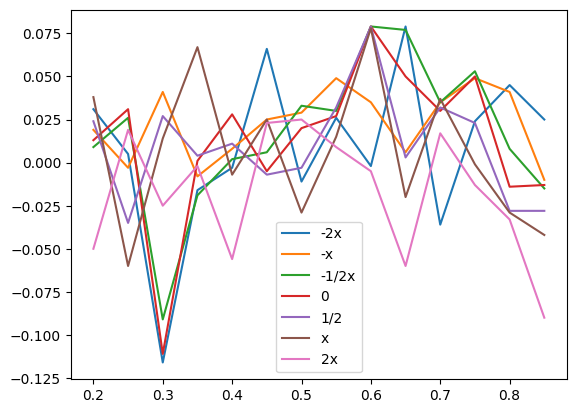

In [53]:
legend = ["-2x","-x","-1/2x","0","1/2","x","2x"]

print(np.shape(all_position))
print(all_position)
for item1 in range(7):
    plt.plot(range_array,all_position[item1])
plt.legend(legend)

In [51]:
import pickle

filename = "model timing comparison"
pickle.dump([all_position, all_width], open(filename, 'wb'))